# cachexia subtypes vs hospitalization and readmission, anchored at cachexia start

Using the cachexia scan START date as time 0. Admission data ends starting 2025.

1. hospitalization incidence
2. time to first hospitalization
3. readmission incidence (30-day)
4. time to readmission
5. same endpoints with death as a competing event

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
from IPython.display import SVG, display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## 0. config and file paths

In [ ]:
SCRIPT_DIR = Path('/gpfs/open-mindphidata/fuc/MSKLabInference/data_cleaning_101023/cachaxia_subtype_hospital_sonia_072526')
DATA_DIR = SCRIPT_DIR / 'data'
OUTPUT_DIR = SCRIPT_DIR / 'out_byctypes_afterstart_fullhistory_091726'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_W_DATE_CSV = DATA_DIR / 'bodycomp_clusters_fortom_09102016.csv'
SEQ_DATE_CSV = DATA_DIR / 'seq_date.csv'
DEATH_LASTCONTACT_CSV = DATA_DIR / 'DMP_ID_death_lastcontact.csv'
ADM_DISCH_CSV = DATA_DIR / 'adm_disch.csv'          
CTYPE_LABELS_CSV = DATA_DIR / 'bodycomp_labels_dmpid_ccx_09172026.csv'
# Superseded 2026-09-17. ctype_impact_df_primary.csv held a primary-IMPACT cancer type for only
# 2,865 of the 4,767 cohort patients (1,902 absent outright, 58 with conflicting types across
# rows), so the by-cancer-type sections ran on 59% of the cohort and only 3 types could clear the
# >=50-per-cluster bar. CTYPE_LABELS_CSV covers all 4,767 and agrees with the cluster file on
# cluster_name and both scan dates for every patient (0 disagreements).
CTYPE_IMPACT_CSV = DATA_DIR / 'ctype_impact_df_primary.csv'  # legacy, no longer read

# --- pre-2023 admission history, recovered by inverting the step-6 de-identification ---
FROZEN_DIR = Path('/gpfs/open-mindphidata/fuc/MSKLabInference/data_cleaning_101023/frozen_data_101623')
DEID_ADM_PICKLE = (FROZEN_DIR / 'frozen_step6_dePHI-ed_data_101623'
                   / 'deidentified_DMP_ID_to_hospital_admission_discharge_dates_tuple_dict.pickle')
FREEZE_COHORT_DIR = FROZEN_DIR / 'frozen_step2_established_cohort_MRN_101623'
MRN_SEQ_DATE_PICKLE = FREEZE_COHORT_DIR / 'MRN_SEQ_DATE_DICT.pickle'
MRN_TO_DMP_ID_PICKLE = FREEZE_COHORT_DIR / 'MRN_to_DMP_ID_dict.pickle'

### TO ASSIGN IF USING #######
#HISTORICAL_DSCH_CEILING = pd.Timestamp('')  # filter used when the pickle was built
#WINDOW_START = pd.Timestamp('')  # legacy floor; NOT used by the end-scan cohort below
#WINDOW_END = pd.Timestamp('')    # last date covered by adm_disch.csv
#DATA_FREEZE = pd.Timestamp('')   # still-open admissions carry this placeholder discharge
CANCELLED_DSCH_TYPES = {'CADM', 'CAPR'}
READMISSION_WINDOWS_DAYS = (30, 90)

# Hospitalization definition across the two eras. The pickle carries dates only: it was built
# with VIS_DSCH_TYPE == 'DSCH' and no VIS_PATIENT_TYPE filter, and patient type cannot be
# recovered from it. 'DSCH_STRICT' applies that same rule to both eras and is the only
# internally consistent option available offline -- note it is broader than inpatient
# (~18% of DSCH rows in the recent extract are urgent care / IPOP rather than IP).
# 'IP_ONLY' reproduces the earlier notebooks but is valid only for the post-2023 era.
HOSP_DEF = 'DSCH_STRICT'

## 1. cohort construction functions

drops patients who died before their entry date. PLA_LAST_CONTACT_DTE is not used to exclude
anyone, it lags real encounters.

In [3]:
def load_full_cohort(cluster_csv, seq_date_csv=SEQ_DATE_CSV,
                      death_lastcontact_csv=DEATH_LASTCONTACT_CSV, window_end=WINDOW_END):
    cluster_df = pd.read_csv(cluster_csv)
    seq_df = pd.read_csv(seq_date_csv, parse_dates=['SEQ_DATE'])
    first_seq = seq_df.groupby('PATIENT_ID')['SEQ_DATE'].min().rename('first_seq_date')

    death_lc = pd.read_csv(death_lastcontact_csv, parse_dates=['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE'])
    death_lc = death_lc.sort_values(['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE']).drop_duplicates('DMP_ID', keep='last')
    death_lc = death_lc.set_index('DMP_ID')[['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE']]

    full_cohort = cluster_df.join(first_seq, on='DMP_ID').join(death_lc, on='DMP_ID')
    full_cohort = full_cohort[
        full_cohort['first_seq_date'].notna() & (full_cohort['first_seq_date'] <= window_end)
    ].copy()
    return full_cohort.set_index('DMP_ID')


# The label file carries MSK detailed subtypes. The analysis groups on the broader cancer types
# used throughout this project and the earlier notebooks, so subtypes are rolled up here. Merges
# worth knowing about: stomach + esophageal adenocarcinoma -> esophagogastric; intrahepatic +
# extrahepatic cholangiocarcinoma + gallbladder -> hepatobiliary; uterine endometrioid + serous
# -> endometrial. Everything else is a one-to-one rename.
DETAILED_TO_BROAD_CTYPE = {
    'Colorectal Adenocarcinoma': 'Colorectal Cancer',
    'Pancreatic Adenocarcinoma': 'Pancreatic Cancer',
    'Lung Adenocarcinoma': 'Non-Small Cell Lung Cancer',
    'High-Grade Serous Ovarian Cancer': 'Ovarian Cancer',
    'Prostate Adenocarcinoma': 'Prostate Cancer',
    'Uterine Endometrioid Carcinoma': 'Endometrial Cancer',
    'Uterine Serous Carcinoma': 'Endometrial Cancer',
    'Breast Invasive Ductal Carcinoma': 'Breast Cancer',
    'Bladder Urothelial Carcinoma': 'Bladder Cancer',
    'Stomach Adenocarcinoma': 'Esophagogastric Cancer',
    'Esophageal Adenocarcinoma': 'Esophagogastric Cancer',
    'Intrahepatic Cholangiocarcinoma': 'Hepatobiliary Cancer',
    'Extrahepatic Cholangiocarcinoma': 'Hepatobiliary Cancer',
    'Gallbladder Cancer': 'Hepatobiliary Cancer',
    'Renal Clear Cell Carcinoma': 'Renal Cell Carcinoma',
    'Cutaneous Melanoma': 'Melanoma',
}


def load_cancer_types(ctype_csv=CTYPE_LABELS_CSV, rollup=DETAILED_TO_BROAD_CTYPE, detailed=False):
    """Each patient's cancer type, keyed by DMP_ID. One row per patient with complete coverage of
    the cluster cohort, so nothing is dropped here and no patient is left unknown. Pass
    detailed=True to group on the raw MSK subtype instead of the broad roll-up."""
    ct = pd.read_csv(ctype_csv)
    assert not ct['DMP_ID'].duplicated().any(), 'expected one row per DMP_ID'
    assert ct['CANCER_TYPE_DETAILED'].notna().all(), 'unlabeled patients in the label file'
    ct = ct.set_index('DMP_ID')['CANCER_TYPE_DETAILED']
    if detailed:
        return ct.rename('CANCER_TYPE')
    unmapped = sorted(set(ct) - set(rollup))
    assert not unmapped, f'detailed subtypes missing from DETAILED_TO_BROAD_CTYPE: {unmapped}'
    return ct.map(rollup).rename('CANCER_TYPE')


def _entry_date(df, extra_entry_col=None):
    entry = df['first_seq_date']
    if extra_entry_col is not None:
        entry = pd.concat([entry, df[extra_entry_col]], axis=1).max(axis=1)
    return entry


def restrict_to_hospitalization_cohort(full_cohort, window_start=WINDOW_START, window_end=WINDOW_END,
                                        extra_entry_col=None):
    cohort = full_cohort.copy()
    cohort['obs_start'] = _entry_date(cohort, extra_entry_col).clip(lower=window_start)

    died_before_start = cohort['PT_DEATH_DTE'].notna() & (cohort['PT_DEATH_DTE'] < cohort['obs_start'])
    cohort = cohort[~died_before_start].copy()

    cohort['died_in_window'] = cohort['PT_DEATH_DTE'].notna() & (cohort['PT_DEATH_DTE'] <= window_end)
    cohort['obs_end'] = np.where(cohort['died_in_window'], cohort['PT_DEATH_DTE'], window_end)
    cohort['obs_end'] = pd.to_datetime(cohort['obs_end'])
    cohort['follow_up_days'] = (cohort['obs_end'] - cohort['obs_start']).dt.days
    assert (cohort['follow_up_days'] >= 0).all()
    return cohort


def load_clean_ip_admissions(cohort_ids, adm_disch_csv=ADM_DISCH_CSV, cancelled_dsch_types=CANCELLED_DSCH_TYPES):
    adm = pd.read_csv(adm_disch_csv, dtype=str)
    adm.columns = [c.strip() for c in adm.columns]
    adm['VIS_PATIENT_TYPE'] = adm['VIS_PATIENT_TYPE'].str.strip()
    adm['VIS_DSCH_TYPE'] = adm['VIS_DSCH_TYPE'].str.strip()
    adm = adm[adm['DMP_ID'].isin(cohort_ids)].copy()
    adm['adm_dte'] = pd.to_datetime(adm['VIS_ADM_DTE'])
    adm['dsch_dte'] = pd.to_datetime(adm['VIS_DSCH_DTE'])

    ip = adm[(adm['VIS_PATIENT_TYPE'] == 'IP') & (~adm['VIS_DSCH_TYPE'].isin(cancelled_dsch_types))].copy()
    ip = ip.sort_values(['DMP_ID', 'adm_dte']).reset_index(drop=True)

    keep = np.ones(len(ip), dtype=bool)
    adm_vals, dsch_vals, pid_vals = ip['adm_dte'].values, ip['dsch_dte'].values, ip['DMP_ID'].values
    running_dsch = dsch_vals.copy()
    for i in range(1, len(ip)):
        if pid_vals[i] == pid_vals[i - 1] and adm_vals[i] <= running_dsch[i - 1]:
            keep[i] = False
            running_dsch[i] = max(running_dsch[i - 1], dsch_vals[i])
            running_dsch[i - 1] = running_dsch[i]
        else:
            running_dsch[i] = dsch_vals[i]
    ip['dsch_dte'] = running_dsch
    return ip[keep].reset_index(drop=True)


def _patient_metrics(admissions_for_patient, obs_start, obs_end, readmission_windows_days, data_freeze):
    adm_p = admissions_for_patient[admissions_for_patient['adm_dte'].between(obs_start, obs_end)].sort_values('adm_dte')
    n_admissions = len(adm_p)
    if n_admissions == 0:
        return {
            'ever_hospitalized': False, 'n_admissions': 0, 'total_los_days': 0,
            'time_to_first_hospitalization_days': (obs_end - obs_start).days,
            'time_to_readmission_days': np.nan, 'readmitted': False,
            **{f'readmitted_{w}d': False for w in readmission_windows_days},
        }
    los_cap = min(data_freeze, obs_end)
    los_days = (adm_p['dsch_dte'].clip(upper=los_cap) - adm_p['adm_dte']).dt.days.clip(lower=0)
    gaps_days = (adm_p['adm_dte'].values[1:] - adm_p['dsch_dte'].values[:-1]).astype('timedelta64[D]').astype(int)
    first_admission_day = (adm_p['adm_dte'].iloc[0] - obs_start).days
    time_to_readmission = int(gaps_days[0]) if n_admissions >= 2 else (obs_end - adm_p['dsch_dte'].iloc[-1]).days
    return {
        'ever_hospitalized': True, 'n_admissions': n_admissions, 'total_los_days': int(los_days.sum()),
        'time_to_first_hospitalization_days': first_admission_day,
        'time_to_readmission_days': time_to_readmission, 'readmitted': n_admissions >= 2,
        **{f'readmitted_{w}d': bool(len(gaps_days) and gaps_days.min() <= w) for w in readmission_windows_days},
    }


def compute_metrics_table(cohort, ip, readmission_windows_days=READMISSION_WINDOWS_DAYS, data_freeze=DATA_FREEZE):
    ip_by_patient = dict(tuple(ip.groupby('DMP_ID')))
    empty_ip = ip.iloc[0:0]
    rows = []
    for dmp_id, row in cohort.iterrows():
        m = _patient_metrics(
            ip_by_patient.get(dmp_id, empty_ip), row['obs_start'], row['obs_end'],
            readmission_windows_days, data_freeze,
        )
        m['DMP_ID'] = dmp_id
        m['cluster_name'] = row['cluster_name']
        m['person_years'] = max(row['follow_up_days'], 1) / 365.25
        rows.append(m)
    return pd.DataFrame(rows)


## 2. admission table, 2015-2025 (pre-2023 + 2023-2025)

In [ ]:
import pickle


def _load_reconstruction_anchor():
    """Use MRN_SEQ_DATE_DICT for reconstructing with it places every discharge on or before
    the 2023  ceiling the pickle was filtered on.
    """
    with open(MRN_SEQ_DATE_PICKLE, 'rb') as fh:
        mrn_seq = pickle.load(fh)
    with open(MRN_TO_DMP_ID_PICKLE, 'rb') as fh:
        mrn_to_dmp = pickle.load(fh)
    return {mrn_to_dmp[mrn]: pd.Timestamp(d) for mrn, d in mrn_seq.items() if mrn in mrn_to_dmp}


def reconstruct_historical_admissions(cohort_ids, anchor):
    """Invert the step-6 date shift. Stored values are (admission, discharge) day offsets from
    the patient's first sequencing date, so adding that date back recovers calendar dates.
    Covers everything up to the 2023 discharge ceiling."""
    with open(DEID_ADM_PICKLE, 'rb') as fh:
        deid = pickle.load(fh)
    rows = []
    for dmp_id, pairs in deid.items():
        if dmp_id not in cohort_ids:
            continue
        origin = anchor.get(dmp_id)
        if origin is None:
            continue
        for adm_off, dsch_off in pairs:
            rows.append((dmp_id,
                         origin + pd.Timedelta(days=int(adm_off)),
                         origin + pd.Timedelta(days=int(dsch_off))))
    out = pd.DataFrame(rows, columns=['DMP_ID', 'adm_dte', 'dsch_dte'])
    out['era'] = 'historical'
    return out


def load_recent_admissions(cohort_ids, hosp_def=HOSP_DEF, adm_disch_csv=ADM_DISCH_CSV):
    """Stays from the 2023 .. 2025 extract."""
    adm = pd.read_csv(adm_disch_csv, dtype=str)
    adm.columns = [c.strip() for c in adm.columns]
    for c in ('VIS_PATIENT_TYPE', 'VIS_DSCH_TYPE'):
        adm[c] = adm[c].str.strip()
    adm = adm[adm['DMP_ID'].isin(cohort_ids)].copy()
    adm['adm_dte'] = pd.to_datetime(adm['VIS_ADM_DTE'])
    adm['dsch_dte'] = pd.to_datetime(adm['VIS_DSCH_DTE'])
    if hosp_def == 'DSCH_STRICT':
        keep = adm['VIS_DSCH_TYPE'] == 'DSCH'
    elif hosp_def == 'IP_ONLY':
        keep = (adm['VIS_PATIENT_TYPE'] == 'IP') & (~adm['VIS_DSCH_TYPE'].isin(CANCELLED_DSCH_TYPES))
    else:
        raise ValueError(f'unknown HOSP_DEF {hosp_def!r}')
    out = adm[keep & adm['adm_dte'].notna() & adm['dsch_dte'].notna()]
    return out[['DMP_ID', 'adm_dte', 'dsch_dte']].assign(era='recent')


def _merge_overlapping_stays(df):
    """Absorb an admission into the previous stay when it starts on or before that stay's
    discharge."""
    df = df.sort_values(['DMP_ID', 'adm_dte']).reset_index(drop=True)
    if df.empty:
        return df
    keep = np.ones(len(df), dtype=bool)
    adm_vals, dsch_vals, pid_vals = df['adm_dte'].values, df['dsch_dte'].values, df['DMP_ID'].values
    running = dsch_vals.copy()
    for i in range(1, len(df)):
        if pid_vals[i] == pid_vals[i - 1] and adm_vals[i] <= running[i - 1]:
            keep[i] = False
            running[i] = max(running[i - 1], dsch_vals[i])
            running[i - 1] = running[i]
        else:
            running[i] = dsch_vals[i]
    df['dsch_dte'] = running
    return df[keep].reset_index(drop=True)


def build_full_history_admissions(cohort_ids, anchor, hosp_def=HOSP_DEF):
    """Reconstructed pre-2023 history + the 2023-2025 extract, de-duplicated across the seam
    and overlap-merged. """
    hist = reconstruct_historical_admissions(cohort_ids, anchor)
    recent = load_recent_admissions(cohort_ids, hosp_def)
    both = pd.concat([hist, recent], ignore_index=True).dropna(subset=['adm_dte', 'dsch_dte'])
    n_before = len(both)
    both = both.drop_duplicates(['DMP_ID', 'adm_dte', 'dsch_dte'])
    print(f'historical stays={len(hist)}  recent stays={len(recent)}  '
          f'duplicates dropped at the seam={n_before - len(both)}')
    return _merge_overlapping_stays(both)


def load_cohort_endscan(cluster_csv=CLUSTER_W_DATE_CSV, death_lastcontact_csv=DEATH_LASTCONTACT_CSV):
    """Cluster assignments + death dates. Unlike the earlier notebooks this does not join
    seq_date.csv, because entry is the cachexia scan end rather than the sequencing date."""
    cluster_df = pd.read_csv(cluster_csv)
    death_lc = pd.read_csv(death_lastcontact_csv, parse_dates=['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE'])
    death_lc = death_lc.sort_values(['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE']).drop_duplicates('DMP_ID', keep='last')
    death_lc = death_lc.set_index('DMP_ID')[['PT_DEATH_DTE', 'PLA_LAST_CONTACT_DTE']]
    full = cluster_df.join(death_lc, on='DMP_ID')
    for c in ('START_CCX_SCAN_DATE', 'END_CCX_SCAN_DATE'):
        full[c] = pd.to_datetime(full[c])
    return full.set_index('DMP_ID')


def restrict_to_startscan_cohort(full_cohort, reconstructable_ids, window_end=WINDOW_END):
    """Time zero is the cachexia scan START date itself.

    Patients without a reconstruction anchor are dropped rather than kept: their pre-2023
    admissions cannot be recovered, so retaining them would make them look event-free by
    construction over exactly the stretch this notebook exists to observe.
    """
    cohort = full_cohort[full_cohort.index.isin(reconstructable_ids)].copy()
    cohort['obs_start'] = cohort['START_CCX_SCAN_DATE']
    cohort = cohort[cohort['obs_start'] <= window_end]

    died_before_start = cohort['PT_DEATH_DTE'].notna() & (cohort['PT_DEATH_DTE'] < cohort['obs_start'])
    cohort = cohort[~died_before_start].copy()

    cohort['died_in_window'] = cohort['PT_DEATH_DTE'].notna() & (cohort['PT_DEATH_DTE'] <= window_end)
    cohort['obs_end'] = pd.to_datetime(np.where(cohort['died_in_window'], cohort['PT_DEATH_DTE'], window_end))
    cohort['follow_up_days'] = (cohort['obs_end'] - cohort['obs_start']).dt.days
    assert (cohort['follow_up_days'] >= 0).all()
    return cohort


## 3. stats and plotting helpers

In [5]:
def pairwise_logrank_with_holm(durations, groups, event_observed):
    """Pairwise log-rank tests between every cluster pair, Holm-corrected."""
    result = pairwise_logrank_test(durations, groups, event_observed)
    pairwise_df = result.summary.reset_index()
    pairwise_df.columns = ['group_1', 'group_2', 'test_statistic', 'p_raw', 'neg_log2_p']
    pairwise_df = pairwise_df[['group_1', 'group_2', 'test_statistic', 'p_raw']]
    pairwise_df = pairwise_df.sort_values('p_raw').reset_index(drop=True)
    m = len(pairwise_df)
    pairwise_df['p_holm'] = [min(1.0, p * (m - i)) for i, p in enumerate(pairwise_df['p_raw'])]
    pairwise_df['p_holm'] = pairwise_df['p_holm'].cummax()
    return pairwise_df


def _pairwise_annotation(pairwise_df, clusters, p_col='p_holm'):
    """Reorders a pairwise result into a fixed A/B, A/C, B/C-style string (canonical cluster
    order, not sorted by significance) for annotating a plot."""
    lookup = {frozenset([row.group_1, row.group_2]): getattr(row, p_col) for row in pairwise_df.itertuples()}
    short = lambda g: g.replace('Type ', '')
    parts = []
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            p = lookup.get(frozenset([clusters[i], clusters[j]]), float('nan'))
            parts.append(f'{short(clusters[i])}/{short(clusters[j])}={p:.3g}')
    return '  '.join(parts)


def _plot_km_on_ax(ax, df, duration_col, event_col, title, xlabel, ylabel, fontsize=10):
    kmf = KaplanMeierFitter()
    for cluster_name, group in df.groupby('cluster_name'):
        kmf.fit(group[duration_col], group[event_col], label=cluster_name)
        kmf.plot_survival_function(ax=ax)

    logrank = multivariate_logrank_test(df[duration_col], df['cluster_name'], df[event_col])
    pairwise_df = pairwise_logrank_with_holm(df[duration_col], df['cluster_name'], df[event_col])
    clusters = sorted(df['cluster_name'].unique())
    pairwise_str = _pairwise_annotation(pairwise_df, clusters)

    stats_fontsize = max(fontsize - 4, 6)
    ax.set_title(title, fontsize=fontsize, pad=22)
    ax.text(0.5, 1.0, f'overall p={logrank.p_value:.3g}   {pairwise_str}',
            transform=ax.transAxes, ha='center', va='bottom', fontsize=stats_fontsize)
    ax.set_xlabel(xlabel, fontsize=fontsize - 1)
    ax.set_ylabel(ylabel, fontsize=fontsize - 1)
    ax.legend(fontsize=fontsize - 2)
    return logrank.p_value, pairwise_df


def _plot_incidence_bar_on_ax(ax, df, outcome_col, ylabel, title, fontsize=10):
    contingency = pd.crosstab(df['cluster_name'], df[outcome_col])
    chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
    rates = df.groupby('cluster_name')[outcome_col].mean().sort_index() * 100
    rates.plot(kind='bar', ax=ax)
    ax.set_title(f'{title}\np = {p_chi2:.3g}', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize - 1)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=fontsize - 2, rotation=0)
    return p_chi2, contingency


def _grid_layout(n, ncols=4):
    ncols = min(ncols, n)
    nrows = -(-n // ncols)  # ceil division
    return nrows, ncols


def _plot_km_with_logrank(df, duration_col, event_col, title, xlabel, ylabel, filename, output_dir):
    fig, ax = plt.subplots(figsize=(7, 5))
    logrank_p, pairwise_df = _plot_km_on_ax(ax, df, duration_col, event_col, title, xlabel, ylabel, fontsize=12)
    fig.tight_layout()
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(output_dir) / filename)
    plt.close(fig)
    return {'logrank_p': logrank_p, 'pairwise': pairwise_df}


def _plot_incidence_bar_with_chi2(df, outcome_col, ylabel, title, filename, output_dir):
    fig, ax = plt.subplots(figsize=(6, 4))
    p_chi2, contingency = _plot_incidence_bar_on_ax(ax, df, outcome_col, ylabel, title, fontsize=12)
    ax.set_xlabel('Cluster')
    fig.tight_layout()
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(output_dir) / filename)
    plt.close(fig)
    return {'chi2_p': p_chi2, 'contingency_table': contingency}


def _plot_km_grid(groups, duration_col, event_col, suptitle, xlabel, ylabel, filename, output_dir, ncols=4):
    nrows, ncols = _grid_layout(len(groups), ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    results = {}
    for i, (label, df) in enumerate(groups):
        ax = axes[i // ncols][i % ncols]
        p, pairwise_df = _plot_km_on_ax(ax, df, duration_col, event_col, label, xlabel, ylabel)
        results[label] = {'logrank_p': p, 'pairwise': pairwise_df}
    for j in range(len(groups), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle(suptitle)
    fig.tight_layout()
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(output_dir) / filename)
    plt.close(fig)
    return results


def _plot_incidence_bar_grid(groups, outcome_col, ylabel, suptitle, filename, output_dir, ncols=4):
    nrows, ncols = _grid_layout(len(groups), ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.2 * nrows), squeeze=False)
    results = {}
    for i, (label, df) in enumerate(groups):
        ax = axes[i // ncols][i % ncols]
        p, contingency = _plot_incidence_bar_on_ax(ax, df, outcome_col, ylabel, label)
        results[label] = {'chi2_p': p, 'contingency_table': contingency}
    for j in range(len(groups), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle(suptitle)
    fig.tight_layout()
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(output_dir) / filename)
    plt.close(fig)
    return results


def summarize_grid_results(results, p_key):
    return pd.DataFrame({label: {'p_value': r[p_key]} for label, r in results.items()}).T.round(4)


## 4. analysis functions for endpoints 1-4

In [6]:
def analyze_hospitalization_incidence(metrics_df, output_dir, filename='hospitalization_incidence_by_cluster.svg',
                                       title='Hospitalization Incidence by Cachexia Cluster'):
    summary = metrics_df.groupby('cluster_name').agg(
        n=('DMP_ID', 'count'),
        pct_hospitalized=('ever_hospitalized', lambda s: 100 * s.mean()),
        n_hospitalized=('ever_hospitalized', 'sum'),
    ).round(2)
    result = _plot_incidence_bar_with_chi2(
        metrics_df, 'ever_hospitalized', '% Ever Hospitalized', title, filename, output_dir,
    )
    result['summary'] = summary
    return result


def analyze_hospitalization_incidence_grid(groups, output_dir, filename='hosp_inc_by_type.svg',
                                            suptitle='Hospitalization Incidence by Cancer Type', ncols=4):
    return _plot_incidence_bar_grid(
        groups, 'ever_hospitalized', '% Ever Hospitalized', suptitle, filename, output_dir, ncols=ncols,
    )


def analyze_time_to_first_hospitalization(metrics_df, output_dir, filename='km_first_hospitalization_by_cluster.svg',
                                           title='Time to First Hospitalization by Cachexia Cluster'):
    df = metrics_df.copy()
    df['ever_hospitalized_int'] = df['ever_hospitalized'].astype(int)
    return _plot_km_with_logrank(
        df, 'time_to_first_hospitalization_days', 'ever_hospitalized_int', title,
        xlabel='Days since cohort entry', ylabel='Event-free probability',
        filename=filename, output_dir=output_dir,
    )


def analyze_time_to_first_hospitalization_grid(groups, output_dir, filename='km_first_hosp_by_type.svg',
                                                suptitle='Time to First Hospitalization by Cancer Type', ncols=4):
    prepped = [(label, df.assign(ever_hospitalized_int=df['ever_hospitalized'].astype(int))) for label, df in groups]
    return _plot_km_grid(
        prepped, 'time_to_first_hospitalization_days', 'ever_hospitalized_int', suptitle,
        xlabel='Days since cohort entry', ylabel='Event-free probability',
        filename=filename, output_dir=output_dir, ncols=ncols,
    )


def analyze_readmission_incidence(metrics_df, output_dir, filename='readmission_rate_by_cluster.svg',
                                   title='Readmission Rate by Cachexia Cluster (Hospitalized Patients)',
                                   window_days=30):
    hospitalized_df = metrics_df[metrics_df['ever_hospitalized']].copy()
    col = f'readmitted_{window_days}d'
    summary = hospitalized_df.groupby('cluster_name').agg(
        n=('DMP_ID', 'count'),
        pct_readmitted=(col, lambda s: 100 * s.mean()),
    ).round(2)
    result = _plot_incidence_bar_with_chi2(
        hospitalized_df, col, f'% Readmitted within {window_days}d', title, filename, output_dir,
    )
    result['summary'] = summary
    return result


def analyze_readmission_incidence_grid(groups, output_dir, filename='readmit_inc_by_type.svg',
                                        suptitle='Readmission Incidence by Cancer Type', window_days=30, ncols=4):
    col = f'readmitted_{window_days}d'
    prepped = [(label, df[df['ever_hospitalized']]) for label, df in groups]
    return _plot_incidence_bar_grid(
        prepped, col, f'% Readmitted within {window_days}d', suptitle, filename, output_dir, ncols=ncols,
    )


def analyze_time_to_readmission(metrics_df, output_dir, filename='km_readmission_by_cluster.svg',
                                 title='Time to Readmission by Cachexia Cluster (Hospitalized Patients)',
                                 window_days=30):
    hospitalized_df = metrics_df[metrics_df['ever_hospitalized']].copy()
    col = f'readmitted_{window_days}d'
    hospitalized_df[f'{col}_int'] = hospitalized_df[col].astype(int)
    return _plot_km_with_logrank(
        hospitalized_df, 'time_to_readmission_days', f'{col}_int', title,
        xlabel='Days since first discharge', ylabel='Event-free probability',
        filename=filename, output_dir=output_dir,
    )


def analyze_time_to_readmission_grid(groups, output_dir, filename='km_readmit_by_type.svg',
                                      suptitle='Time to Readmission by Cancer Type', window_days=30, ncols=4):
    col = f'readmitted_{window_days}d'
    prepped = []
    for label, df in groups:
        hosp = df[df['ever_hospitalized']].copy()
        hosp[f'{col}_int'] = hosp[col].astype(int)
        prepped.append((label, hosp))
    return _plot_km_grid(
        prepped, 'time_to_readmission_days', f'{col}_int', suptitle,
        xlabel='Days since first discharge', ylabel='Event-free probability',
        filename=filename, output_dir=output_dir, ncols=ncols,
    )


## 5. build the cohort

In [ ]:
anchor = _load_reconstruction_anchor()
full_cohort = load_cohort_endscan()

reconstructable = set(full_cohort.index) & set(anchor)
print(f"Cluster patients: {len(full_cohort)} | with a reconstruction anchor: {len(reconstructable)} "
      f"({100 * len(reconstructable) / len(full_cohort):.1f}%) | dropped: {len(full_cohort) - len(reconstructable)}")

cohort = restrict_to_startscan_cohort(full_cohort, reconstructable)
ip = build_full_history_admissions(set(cohort.index), anchor)
metrics_df = compute_metrics_table(cohort, ip)

print(f"\nStart-scan-anchored cohort: {len(cohort)} patients  (HOSP_DEF = {HOSP_DEF})")
display(cohort['cluster_name'].value_counts())
print(f"Follow-up from cachexia scan start: median {cohort['follow_up_days'].median():.0f} d, "
      f"mean {cohort['follow_up_days'].mean():.0f} d")
print(f"Admission history spans {ip['adm_dte'].min().date()} .. {ip['adm_dte'].max().date()}")
print(f"Patients ever hospitalized after scan start: {metrics_df['ever_hospitalized'].sum()} / {len(metrics_df)}")


### check the reconstruction

In [ ]:
_ids = set(cohort.index)
_hist = reconstruct_historical_admissions(_ids, anchor)
_viol = (_hist['dsch_dte'] > HISTORICAL_DSCH_CEILING).sum()
print(f"1. reconstructed discharges after {HISTORICAL_DSCH_CEILING.date()}: {_viol}  (expect 0)")

_recent = load_recent_admissions(_ids, hosp_def='DSCH_STRICT')
## SET THIS
_lo = pd.Timestamp('')
_h = _hist[(_hist.dsch_dte >= _lo) & (_hist.adm_dte >= _lo)]
_r = _recent[(_recent.dsch_dte <= HISTORICAL_DSCH_CEILING) & (_recent.adm_dte >= _lo)]
_sh = set(zip(_h.DMP_ID, _h.adm_dte, _h.dsch_dte))
_sr = set(zip(_r.DMP_ID, _r.adm_dte, _r.dsch_dte))
_matched = len(_sh & _sr)
print(f"2. overlap window -- reconstructed {len(_sh)}, extract {len(_sr)}, exact matches {_matched}"
      + (f"  ({100 * _matched / len(_sh):.1f}% of reconstructed)" if _sh else ""))


## 6. run and display all 4 endpoints

In [9]:
def show_four_analyses(metrics_sub, label, slug):
    print(f"n = {len(metrics_sub)} (hospitalization cohort)")

    r1 = analyze_hospitalization_incidence(metrics_sub, OUTPUT_DIR, filename=f'hosp_inc_{slug}.svg',
                                            title=f'Hospitalization Incidence -- {label}')
    print(f"\n1. Hospitalization incidence -- chi-square p = {r1['chi2_p']:.4g}")
    display(SVG(filename=f'{OUTPUT_DIR}/hosp_inc_{slug}.svg'))
    display(r1['summary'])

    r2 = analyze_time_to_first_hospitalization(metrics_sub, OUTPUT_DIR, filename=f'km_first_hosp_{slug}.svg',
                                                title=f'Time to First Hospitalization -- {label}')
    print(f"\n2. Time to first hospitalization -- log-rank p = {r2['logrank_p']:.4g}")
    display(SVG(filename=f'{OUTPUT_DIR}/km_first_hosp_{slug}.svg'))
    display(r2['pairwise'])

    r3 = analyze_readmission_incidence(metrics_sub, OUTPUT_DIR, filename=f'readmit_inc_{slug}.svg',
                                        title=f'Readmission Incidence -- {label}')
    print(f"\n3. Readmission incidence (30d) -- chi-square p = {r3['chi2_p']:.4g}")
    display(SVG(filename=f'{OUTPUT_DIR}/readmit_inc_{slug}.svg'))
    display(r3['summary'])

    r4 = analyze_time_to_readmission(metrics_sub, OUTPUT_DIR, filename=f'km_readmit_{slug}.svg',
                                      title=f'Time to Readmission -- {label}')
    print(f"\n4. Time to readmission -- log-rank p = {r4['logrank_p']:.4g}")
    display(SVG(filename=f'{OUTPUT_DIR}/km_readmit_{slug}.svg'))
    display(r4['pairwise'])

    return {'hosp_incidence': r1, 'time_to_first_hosp': r2, 'readmit_incidence': r3, 'time_to_readmit': r4}


## 7. overall, all cancer types together

n = 4683 (hospitalization cohort)

1. Hospitalization incidence -- chi-square p = 0.9741


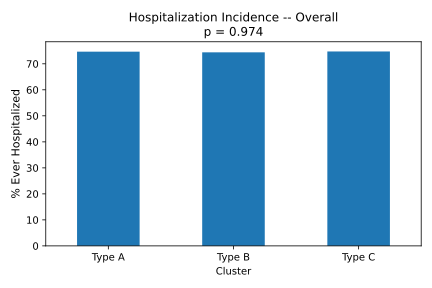

,n,pct_hospitalized,n_hospitalized
cluster_name,,,
Type A,1212,74.67,905
Type B,1563,74.41,1163
Type C,1908,74.74,1426



2. Time to first hospitalization -- log-rank p = 0.1501


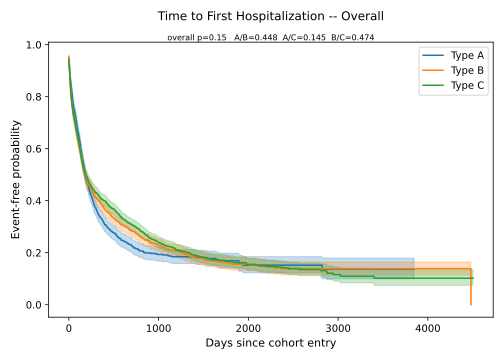

,group_1,group_2,test_statistic,p_raw,p_holm
0,Type A,Type C,3.902466,0.048215,0.144646
1,Type A,Type B,1.478496,0.224010,0.448020
2,Type B,Type C,0.511588,0.474452,0.474452



3. Readmission incidence (30d) -- chi-square p = 0.008964


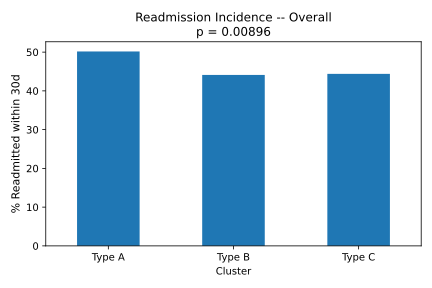

,n,pct_readmitted
cluster_name,,
Type A,905,50.17
Type B,1163,44.11
Type C,1426,44.39



4. Time to readmission -- log-rank p = 9.905e-08


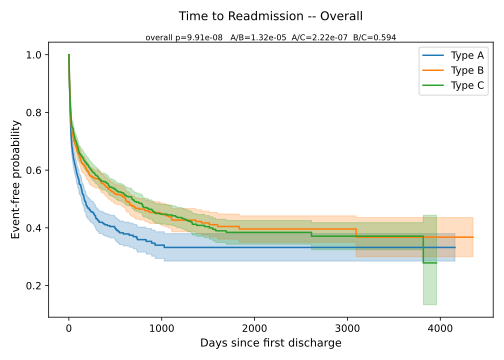

,group_1,group_2,test_statistic,p_raw,p_holm
0,Type A,Type C,28.953859,7.412300e-08,2.223690e-07
1,Type A,Type B,20.302343,6.611956e-06,1.322391e-05
2,Type B,Type C,0.283570,5.943705e-01,5.943705e-01


In [10]:
overall_results = show_four_analyses(metrics_df, label='Overall', slug='overall')


## 8. by cancer type

only analyzed separately if every cluster has >= 50 patients

In [11]:
cancer_types = load_cancer_types()  # from bodycomp_labels_dmpid_ccx_09172026.csv, all 4,767 patients labeled

full_cohort_dx = full_cohort.join(cancer_types)
metrics_df_dx = metrics_df.merge(cancer_types.reset_index(), on='DMP_ID', how='left')

type_counts = full_cohort_dx.groupby(['CANCER_TYPE', 'cluster_name']).size().unstack(fill_value=0)
qualifying_types = type_counts[(type_counts >= 50).all(axis=1)]
print("Cancer types with >=50 patients in every cluster:")
display(qualifying_types)


Cancer types with >=50 patients in every cluster:


cluster_name,Type A,Type B,Type C
CANCER_TYPE,,,
Breast Cancer,56,63,60
Colorectal Cancer,322,375,534
Endometrial Cancer,59,130,137
Esophagogastric Cancer,75,120,62
Hepatobiliary Cancer,63,73,106
Non-Small Cell Lung Cancer,128,216,233
Ovarian Cancer,64,181,256
Pancreatic Cancer,278,214,250
Prostate Cancer,85,72,130


In [12]:
def _counts_with_total(df, types):
    t = df[df['CANCER_TYPE'].isin(types)].groupby(['CANCER_TYPE', 'cluster_name']).size().unstack(fill_value=0)
    t['Total'] = t.sum(axis=1)
    return t.loc[types]

types = qualifying_types.index.tolist()

print("Full cohort:")
display(_counts_with_total(full_cohort_dx, types))

print("\nHospitalization cohort (metrics_df_dx):")
display(_counts_with_total(metrics_df_dx, types))


Full cohort:


cluster_name,Type A,Type B,Type C,Total
CANCER_TYPE,,,,
Breast Cancer,56,63,60,179
Colorectal Cancer,322,375,534,1231
Endometrial Cancer,59,130,137,326
Esophagogastric Cancer,75,120,62,257
Hepatobiliary Cancer,63,73,106,242
Non-Small Cell Lung Cancer,128,216,233,577
Ovarian Cancer,64,181,256,501
Pancreatic Cancer,278,214,250,742
Prostate Cancer,85,72,130,287



Hospitalization cohort (metrics_df_dx):


cluster_name,Type A,Type B,Type C,Total
CANCER_TYPE,,,,
Breast Cancer,55,63,60,178
Colorectal Cancer,314,365,519,1198
Endometrial Cancer,59,127,135,321
Esophagogastric Cancer,75,115,61,251
Hepatobiliary Cancer,63,72,104,239
Non-Small Cell Lung Cancer,125,215,230,570
Ovarian Cancer,64,179,252,495
Pancreatic Cancer,275,212,243,730
Prostate Cancer,83,72,129,284


one figure per endpoint, one subplot per cancer type, then the p-value table

In [13]:
metrics_groups = [(ct, metrics_df_dx[metrics_df_dx['CANCER_TYPE'] == ct]) for ct in qualifying_types.index]


### 8.1 hospitalization incidence

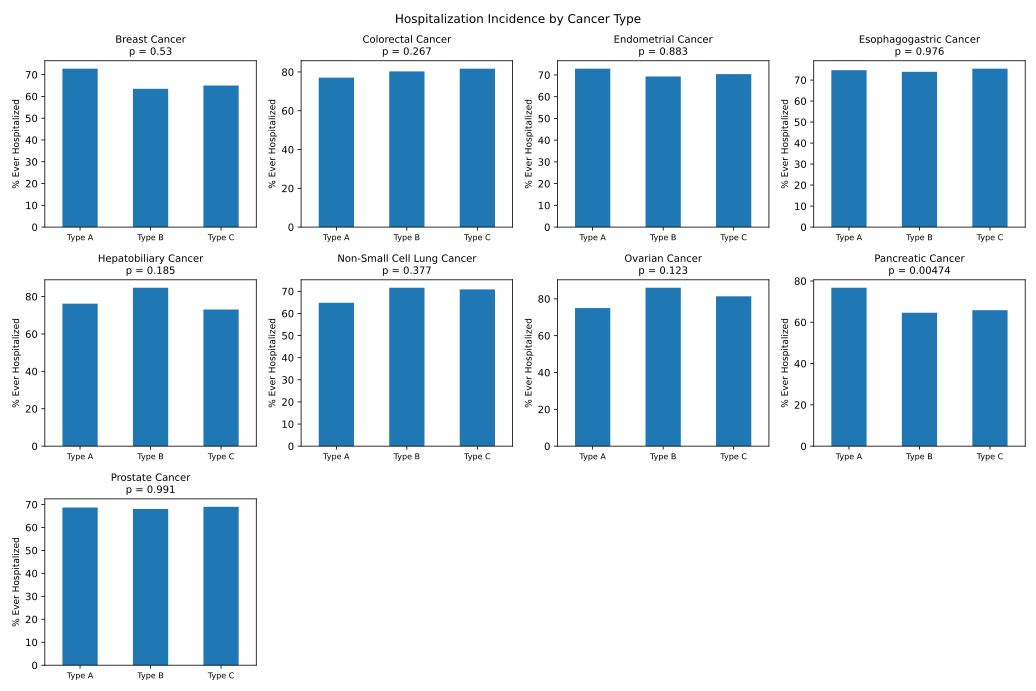

,p_value
Breast Cancer,0.5298
Colorectal Cancer,0.2675
Endometrial Cancer,0.8828
Esophagogastric Cancer,0.9760
Hepatobiliary Cancer,0.1853
Non-Small Cell Lung Cancer,0.3774
Ovarian Cancer,0.1228
Pancreatic Cancer,0.0047
Prostate Cancer,0.9906


In [14]:
r1 = analyze_hospitalization_incidence_grid(metrics_groups, OUTPUT_DIR, filename='hosp_inc_by_type.svg')
display(SVG(filename=f'{OUTPUT_DIR}/hosp_inc_by_type.svg'))
summarize_grid_results(r1, 'chi2_p')


### 8.2 time to first hospitalization

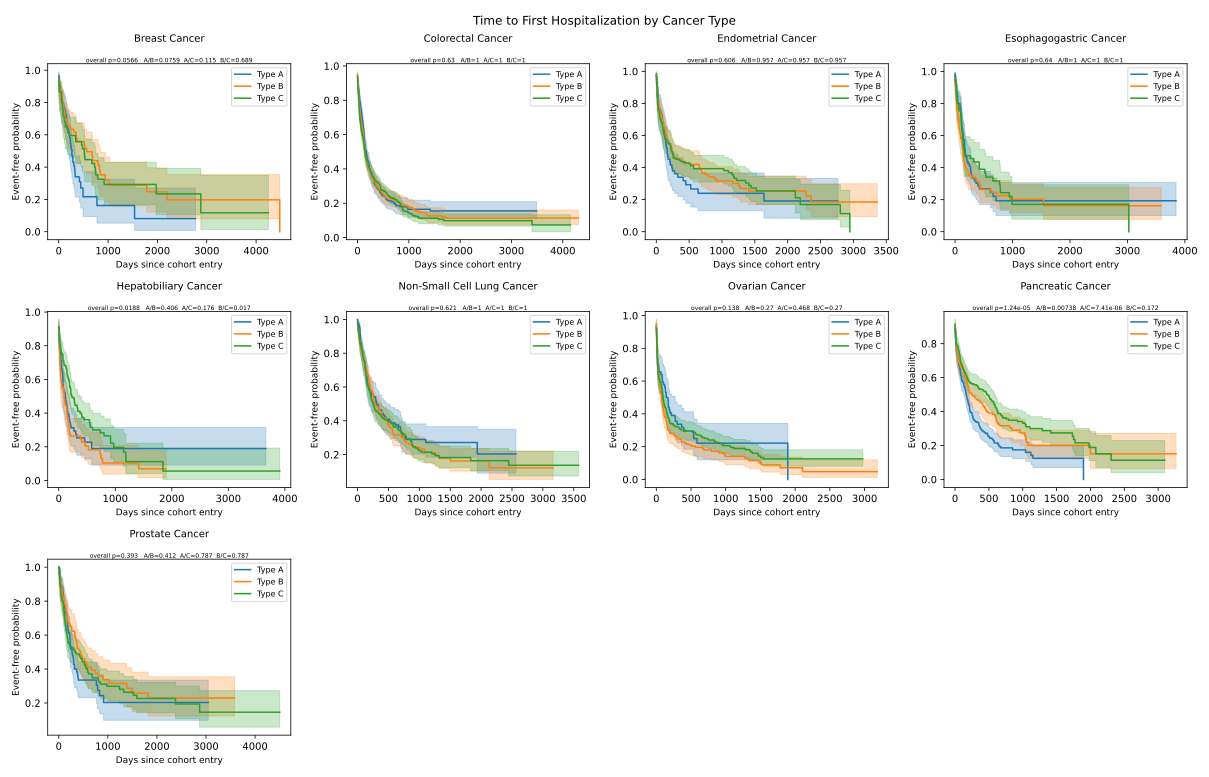

,p_value
Breast Cancer,0.0566
Colorectal Cancer,0.6301
Endometrial Cancer,0.6061
Esophagogastric Cancer,0.6399
Hepatobiliary Cancer,0.0188
Non-Small Cell Lung Cancer,0.6206
Ovarian Cancer,0.1375
Pancreatic Cancer,0.0000
Prostate Cancer,0.3926


In [15]:
r2 = analyze_time_to_first_hospitalization_grid(metrics_groups, OUTPUT_DIR, filename='km_first_hosp_by_type.svg')
display(SVG(filename=f'{OUTPUT_DIR}/km_first_hosp_by_type.svg'))
summarize_grid_results(r2, 'logrank_p')


### 8.3 readmission incidence

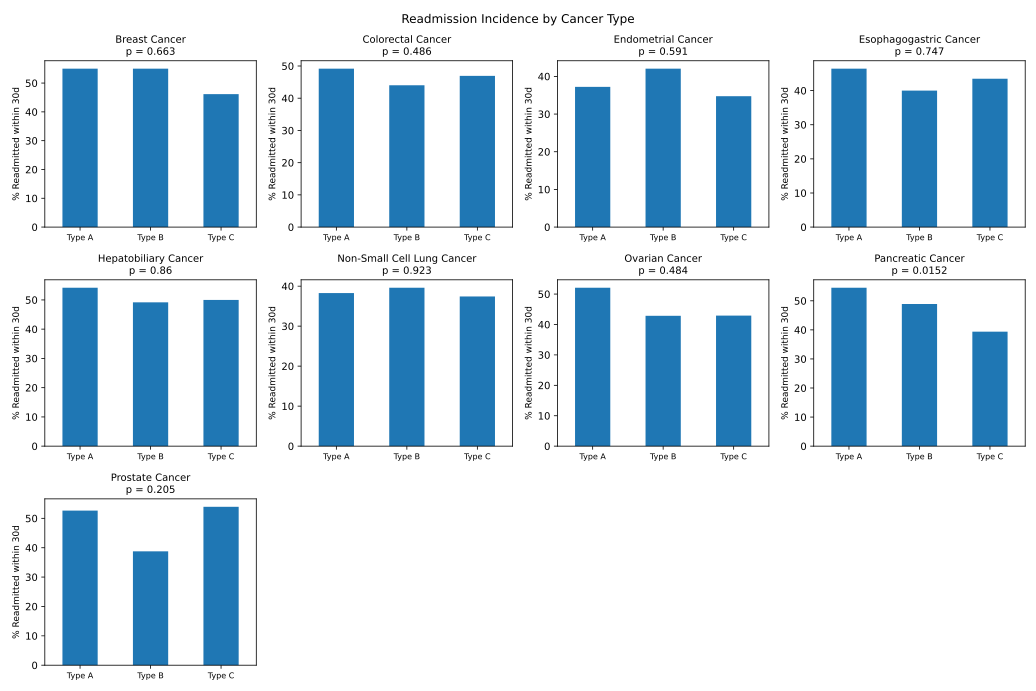

,p_value
Breast Cancer,0.6629
Colorectal Cancer,0.4862
Endometrial Cancer,0.5912
Esophagogastric Cancer,0.7475
Hepatobiliary Cancer,0.8602
Non-Small Cell Lung Cancer,0.9225
Ovarian Cancer,0.4842
Pancreatic Cancer,0.0152
Prostate Cancer,0.2047


In [16]:
r3 = analyze_readmission_incidence_grid(metrics_groups, OUTPUT_DIR, filename='readmit_inc_by_type.svg')
display(SVG(filename=f'{OUTPUT_DIR}/readmit_inc_by_type.svg'))
summarize_grid_results(r3, 'chi2_p')


### 8.4 time to readmission

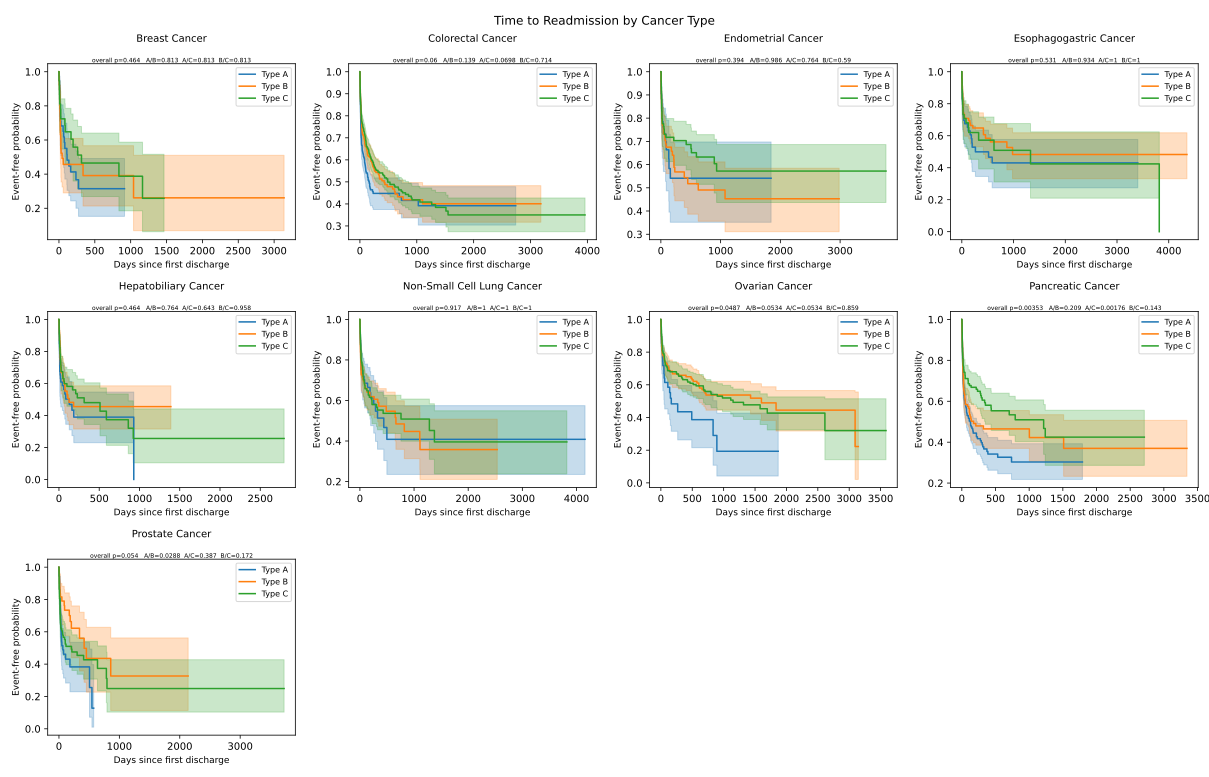

,p_value
Breast Cancer,0.4643
Colorectal Cancer,0.0600
Endometrial Cancer,0.3938
Esophagogastric Cancer,0.5312
Hepatobiliary Cancer,0.4637
Non-Small Cell Lung Cancer,0.9168
Ovarian Cancer,0.0487
Pancreatic Cancer,0.0035
Prostate Cancer,0.0540


In [17]:
r4 = analyze_time_to_readmission_grid(metrics_groups, OUTPUT_DIR, filename='km_readmit_by_type.svg')
display(SVG(filename=f'{OUTPUT_DIR}/km_readmit_by_type.svg'))
summarize_grid_results(r4, 'logrank_p')


## 9. export the underlying data

aggregate numbers behind every plot: KM step functions with 95% CI, incidence summaries and
p-values. cluster / cancer-type level only, no patient rows.

In [18]:
EXPORT_DIR = SCRIPT_DIR / 'data_export_afterstart_fullhistory_091726'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

groups = [('Overall', metrics_df)] + [(ct, metrics_df_dx[metrics_df_dx['CANCER_TYPE'] == ct])
                                       for ct in qualifying_types.index]


def incidence_summary_table(df, outcome_col):
    contingency = pd.crosstab(df['cluster_name'], df[outcome_col])
    chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
    summary = df.groupby('cluster_name').agg(
        n=('DMP_ID', 'count'),
        n_event=(outcome_col, 'sum'),
        pct_event=(outcome_col, lambda s: 100 * s.mean()),
    ).reset_index()
    summary['chi2_p'] = p_chi2
    return summary


def km_curve_table(df, duration_col, event_col):
    # Tidy KM step-function data (time, survival probability, 95% CI) per cluster.
    rows = []
    for cluster_name, g in df.groupby('cluster_name'):
        kmf = KaplanMeierFitter()
        kmf.fit(g[duration_col], g[event_col], label=cluster_name)
        sf = kmf.survival_function_.reset_index()
        sf.columns = ['time_days', 'survival_probability']
        ci = kmf.confidence_interval_.reset_index()
        ci.columns = ['time_days', 'ci_lower', 'ci_upper']
        curve = sf.merge(ci, on='time_days')
        curve.insert(0, 'cluster_name', cluster_name)
        rows.append(curve)
    curve_df = pd.concat(rows, ignore_index=True)
    logrank_p = multivariate_logrank_test(df[duration_col], df['cluster_name'], df[event_col]).p_value
    curve_df['overall_logrank_p'] = logrank_p
    return curve_df


In [19]:
# 1. Hospitalization incidence
hosp_inc_export = pd.concat(
    [incidence_summary_table(df, 'ever_hospitalized').assign(group=label) for label, df in groups],
    ignore_index=True,
)
hosp_inc_export = hosp_inc_export[['group', 'cluster_name', 'n', 'n_event', 'pct_event', 'chi2_p']]
hosp_inc_export.to_csv(EXPORT_DIR / 'hospitalization_incidence.csv', index=False)

# 2. Time to first hospitalization
tfh_curves, tfh_pairwise = [], []
for label, df in groups:
    d = df.copy()
    d['ever_hospitalized_int'] = d['ever_hospitalized'].astype(int)
    tfh_curves.append(km_curve_table(d, 'time_to_first_hospitalization_days', 'ever_hospitalized_int').assign(group=label))
    tfh_pairwise.append(pairwise_logrank_with_holm(
        d['time_to_first_hospitalization_days'], d['cluster_name'], d['ever_hospitalized_int']).assign(group=label))
tfh_curve_export = pd.concat(tfh_curves, ignore_index=True)
tfh_curve_export = tfh_curve_export[['group', 'cluster_name', 'time_days', 'survival_probability',
                                     'ci_lower', 'ci_upper', 'overall_logrank_p']]
tfh_curve_export.to_csv(EXPORT_DIR / 'time_to_first_hospitalization_km_curve.csv', index=False)
tfh_pairwise_export = pd.concat(tfh_pairwise, ignore_index=True)
tfh_pairwise_export = tfh_pairwise_export[['group', 'group_1', 'group_2', 'test_statistic', 'p_raw', 'p_holm']]
tfh_pairwise_export.to_csv(EXPORT_DIR / 'time_to_first_hospitalization_pairwise_pvalues.csv', index=False)

# 3. Readmission incidence (30-day)
readmit_inc_export = pd.concat(
    [incidence_summary_table(df[df['ever_hospitalized']], 'readmitted_30d').assign(group=label) for label, df in groups],
    ignore_index=True,
)
readmit_inc_export = readmit_inc_export[['group', 'cluster_name', 'n', 'n_event', 'pct_event', 'chi2_p']]
readmit_inc_export.to_csv(EXPORT_DIR / 'readmission_incidence.csv', index=False)

# 4. Time to readmission
tr_curves, tr_pairwise = [], []
for label, df in groups:
    hosp = df[df['ever_hospitalized']].copy()
    hosp['readmitted_30d_int'] = hosp['readmitted_30d'].astype(int)
    tr_curves.append(km_curve_table(hosp, 'time_to_readmission_days', 'readmitted_30d_int').assign(group=label))
    tr_pairwise.append(pairwise_logrank_with_holm(
        hosp['time_to_readmission_days'], hosp['cluster_name'], hosp['readmitted_30d_int']).assign(group=label))
tr_curve_export = pd.concat(tr_curves, ignore_index=True)
tr_curve_export = tr_curve_export[['group', 'cluster_name', 'time_days', 'survival_probability',
                                   'ci_lower', 'ci_upper', 'overall_logrank_p']]
tr_curve_export.to_csv(EXPORT_DIR / 'time_to_readmission_km_curve.csv', index=False)
tr_pairwise_export = pd.concat(tr_pairwise, ignore_index=True)
tr_pairwise_export = tr_pairwise_export[['group', 'group_1', 'group_2', 'test_statistic', 'p_raw', 'p_holm']]
tr_pairwise_export.to_csv(EXPORT_DIR / 'time_to_readmission_pairwise_pvalues.csv', index=False)

print(f"Exported to {EXPORT_DIR}:")
for f in sorted(EXPORT_DIR.glob('*.csv')):
    print(' -', f.name)


Exported to /gpfs/open-mindphidata/fuc/MSKLabInference/data_cleaning_101023/cachaxia_subtype_hospital_sonia_072526/data_export_afterstart_fullhistory_091726:
 - hospitalization_incidence.csv
 - readmission_incidence.csv
 - time_to_first_hospitalization_km_curve.csv
 - time_to_first_hospitalization_pairwise_pvalues.csv
 - time_to_readmission_km_curve.csv
 - time_to_readmission_pairwise_pvalues.csv


## 10. replot from the exported CSVs

check that data_export_afterstart_fullhistory_091726/ on its own is enough to redraw everything

In [20]:
FROM_CSV_DIR = OUTPUT_DIR / 'from_csv'
FROM_CSV_DIR.mkdir(parents=True, exist_ok=True)


def plot_incidence_from_csv(csv_path, ylabel, suptitle, filename, ncols=4):
    df = pd.read_csv(csv_path)
    group_order = list(dict.fromkeys(df['group']))  # preserve first-seen order
    nrows, ncols = _grid_layout(len(group_order), ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.2 * nrows), squeeze=False)
    for i, g in enumerate(group_order):
        ax = axes[i // ncols][i % ncols]
        sub = df[df['group'] == g].set_index('cluster_name')['pct_event'].sort_index()
        sub.plot(kind='bar', ax=ax)
        p = df.loc[df['group'] == g, 'chi2_p'].iloc[0]
        ax.set_title(f'{g}\np = {p:.3g}', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=8, rotation=0)
    for j in range(len(group_order), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle(suptitle)
    fig.tight_layout()
    fig.savefig(FROM_CSV_DIR / filename)
    plt.close(fig)
    display(SVG(filename=str(FROM_CSV_DIR / filename)))


def plot_km_from_csv(curve_csv_path, xlabel, suptitle, filename, ncols=4):
    curves = pd.read_csv(curve_csv_path)
    group_order = list(dict.fromkeys(curves['group']))
    nrows, ncols = _grid_layout(len(group_order), ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    for i, g in enumerate(group_order):
        ax = axes[i // ncols][i % ncols]
        sub = curves[curves['group'] == g]
        for cluster_name, cg in sub.groupby('cluster_name'):
            cg = cg.sort_values('time_days')
            ax.step(cg['time_days'], cg['survival_probability'], where='post', label=cluster_name)
            ax.fill_between(cg['time_days'], cg['ci_lower'], cg['ci_upper'], step='post', alpha=0.2)
        overall_p = sub['overall_logrank_p'].iloc[0]
        ax.set_title(f'{g}\noverall p = {overall_p:.3g}', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Event-free probability', fontsize=9)
        ax.legend(fontsize=7)
    for j in range(len(group_order), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle(suptitle)
    fig.tight_layout()
    fig.savefig(FROM_CSV_DIR / filename)
    plt.close(fig)
    display(SVG(filename=str(FROM_CSV_DIR / filename)))


### 10.1 hospitalization incidence

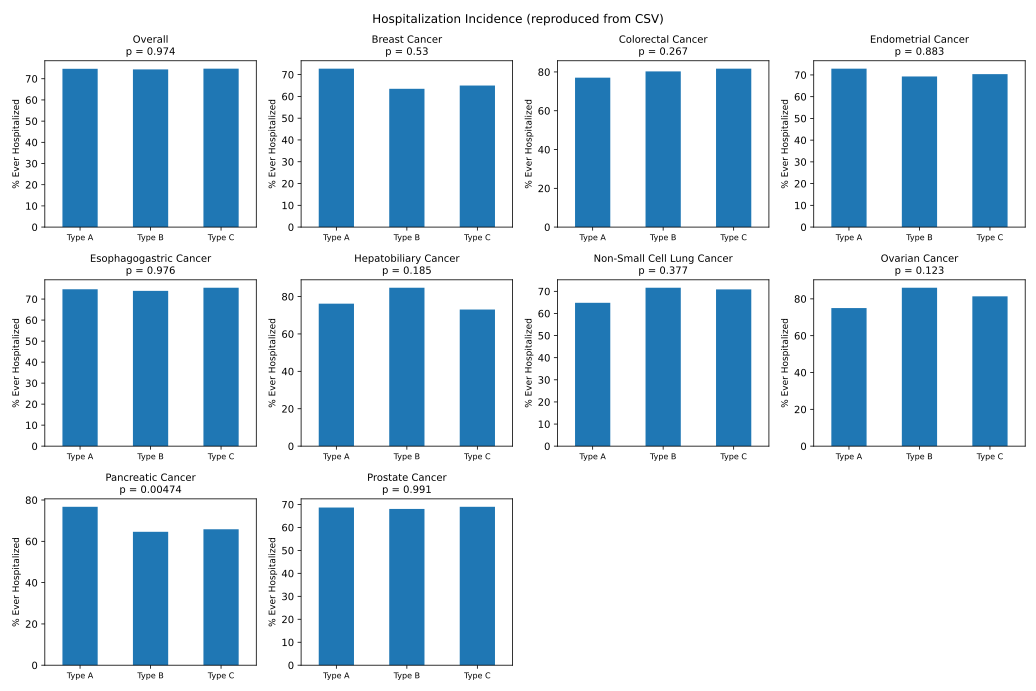

In [21]:
plot_incidence_from_csv(
    EXPORT_DIR / 'hospitalization_incidence.csv',
    ylabel='% Ever Hospitalized',
    suptitle='Hospitalization Incidence (reproduced from CSV)',
    filename='hosp_inc_from_csv.svg',
)


### 10.2 time to first hospitalization

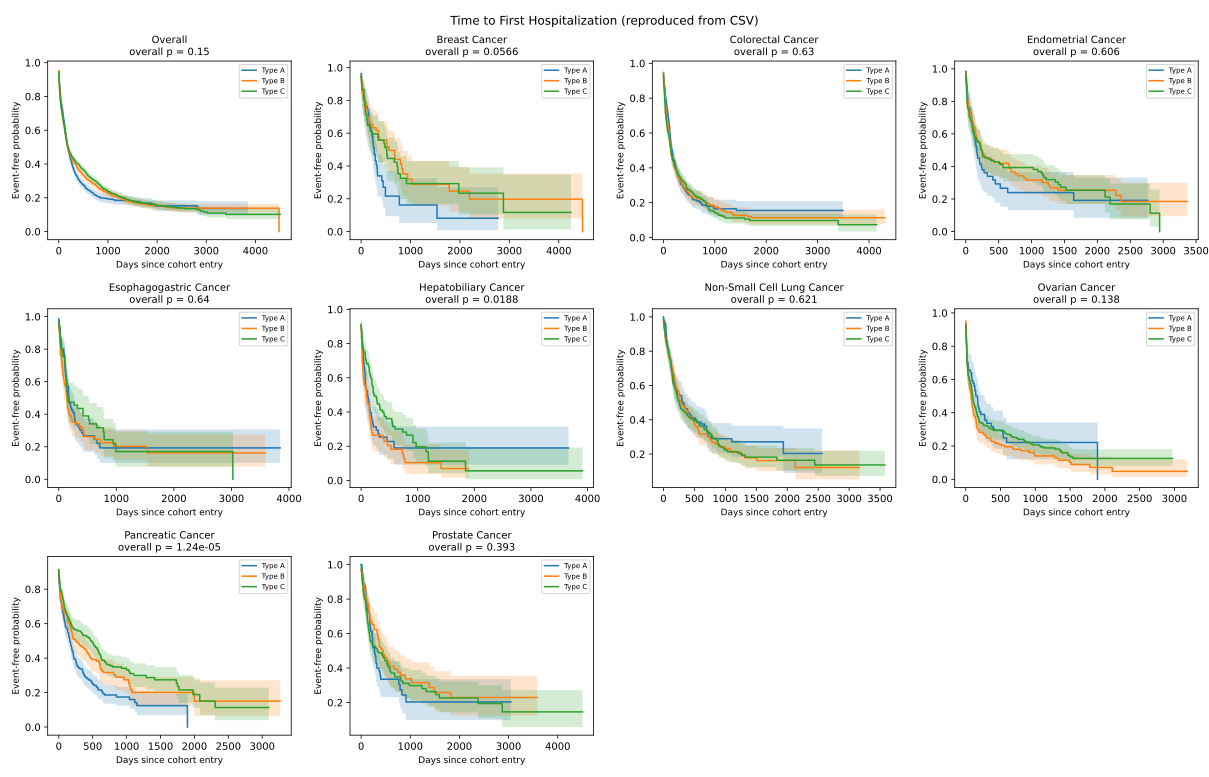

,group,group_1,group_2,test_statistic,p_raw,p_holm
0,Overall,Type A,Type C,3.902466,0.048215,0.144646
1,Overall,Type A,Type B,1.478496,0.224010,0.448020
2,Overall,Type B,Type C,0.511588,0.474452,0.474452
3,Breast Cancer,Type A,Type B,5.003783,0.025292,0.075876
4,Breast Cancer,Type A,Type C,3.600876,0.057749,0.115498
5,Breast Cancer,Type B,Type C,0.160368,0.688818,0.688818
6,Colorectal Cancer,Type A,Type C,0.802138,0.370455,1.000000
7,Colorectal Cancer,Type A,Type B,0.384220,0.535354,1.000000
8,Colorectal Cancer,Type B,Type C,0.171933,0.678400,1.000000
9,Endometrial Cancer,Type A,Type B,0.993272,0.318944,0.956832


In [22]:
plot_km_from_csv(
    EXPORT_DIR / 'time_to_first_hospitalization_km_curve.csv',
    xlabel='Days since cohort entry',
    suptitle='Time to First Hospitalization (reproduced from CSV)',
    filename='km_first_hosp_from_csv.svg',
)
display(pd.read_csv(EXPORT_DIR / 'time_to_first_hospitalization_pairwise_pvalues.csv'))


### 10.3 readmission incidence

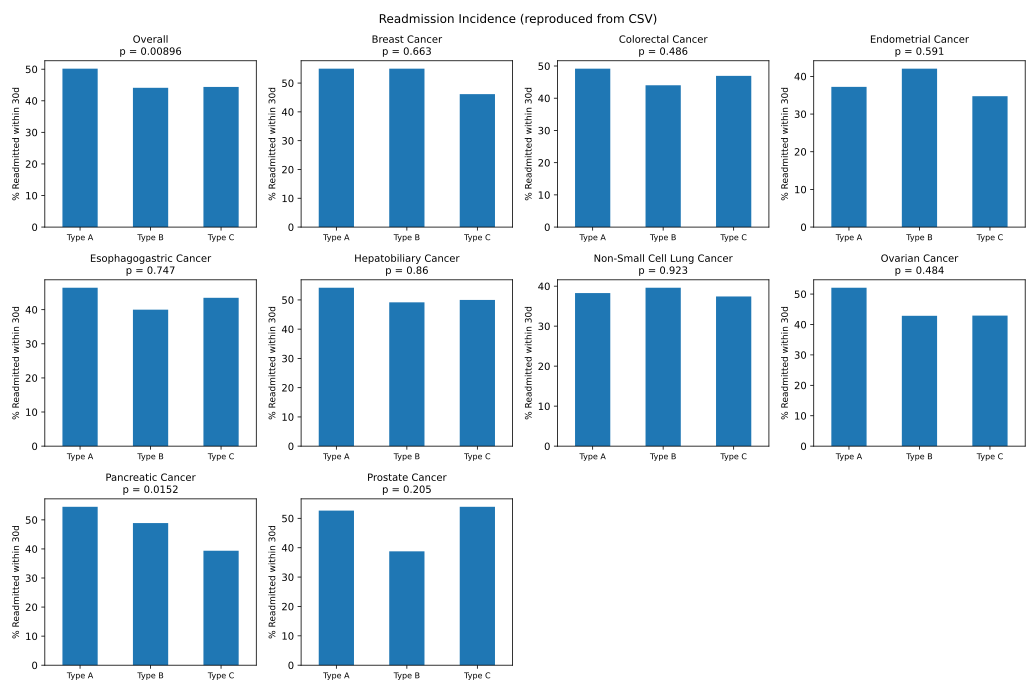

In [23]:
plot_incidence_from_csv(
    EXPORT_DIR / 'readmission_incidence.csv',
    ylabel='% Readmitted within 30d',
    suptitle='Readmission Incidence (reproduced from CSV)',
    filename='readmit_inc_from_csv.svg',
)


### 10.4 time to readmission

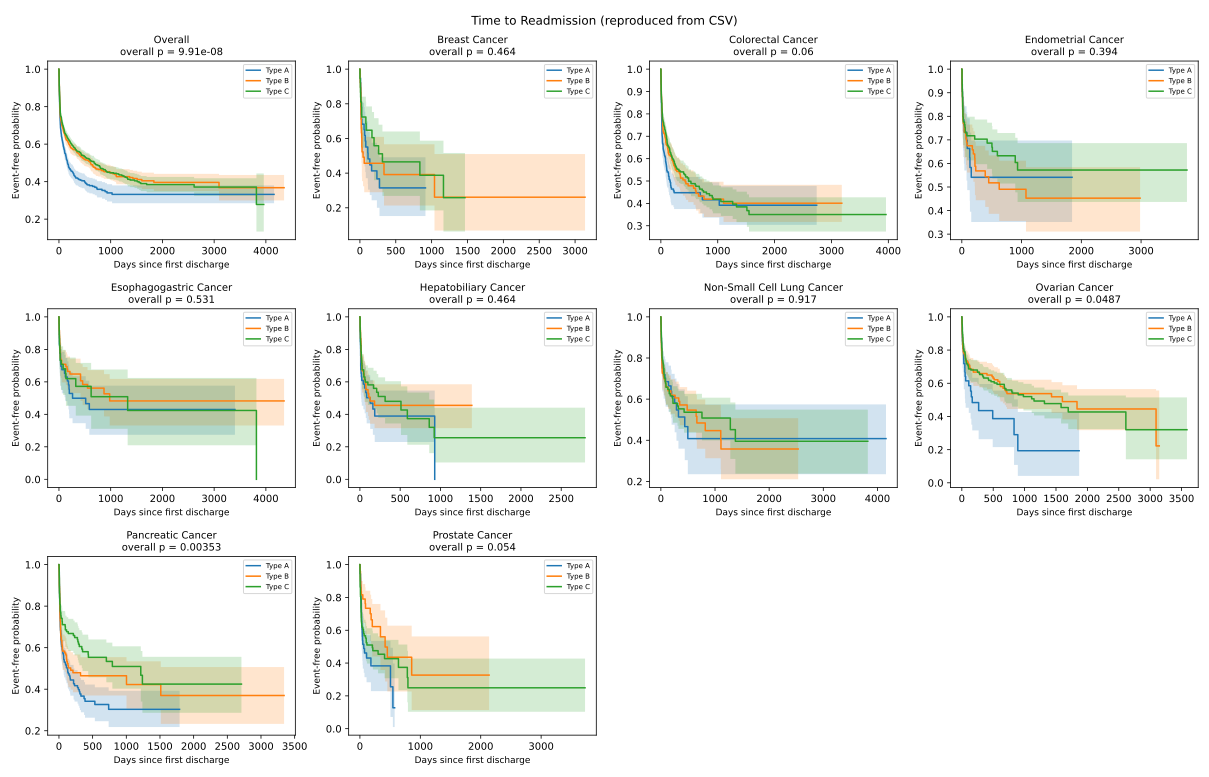

,group,group_1,group_2,test_statistic,p_raw,p_holm
0,Overall,Type A,Type C,28.953859,7.412300e-08,2.223690e-07
1,Overall,Type A,Type B,20.302343,6.611956e-06,1.322391e-05
2,Overall,Type B,Type C,0.283570,5.943705e-01,5.943705e-01
3,Breast Cancer,Type A,Type C,1.211156,2.711034e-01,8.133101e-01
4,Breast Cancer,Type B,Type C,1.085202,2.975367e-01,8.133101e-01
5,Breast Cancer,Type A,Type B,0.056971,8.113483e-01,8.133101e-01
6,Colorectal Cancer,Type A,Type C,5.147945,2.327390e-02,6.982170e-02
7,Colorectal Cancer,Type A,Type B,3.292966,6.957723e-02,1.391545e-01
8,Colorectal Cancer,Type B,Type C,0.134092,7.142261e-01,7.142261e-01
9,Endometrial Cancer,Type B,Type C,1.668181,1.965024e-01,5.895071e-01


In [24]:
plot_km_from_csv(
    EXPORT_DIR / 'time_to_readmission_km_curve.csv',
    xlabel='Days since first discharge',
    suptitle='Time to Readmission (reproduced from CSV)',
    filename='km_readmit_from_csv.svg',
)
display(pd.read_csv(EXPORT_DIR / 'time_to_readmission_pairwise_pvalues.csv'))


# 11. same endpoints, death as a competing event

endpoints 1-4 censor at death, which is a problem here. Type A patients die a lot sooner than
Type C, so they leave observation exactly because they are dying and end up looking like they
have a low burden.

three models below, they answer different questions:
- negative binomial rate with a log(person-years at risk) offset: how often per year at risk
- cause-specific cox: among patients still at risk, does the hazard differ
- fine-gray: does the cumulative fraction differ, given that many die first

plus aalen-johansen cumulative incidence and gray's test.

In [25]:
import statsmodels.api as sm
from scipy.stats import norm
from comprisk import CumulativeIncidence, FineGrayRegression, CauseSpecificCox, gray_test

clusters = ['Type A', 'Type B', 'Type C']
reference_cluster = 'Type C'
cluster_colors = {'Type A': '#c44e52', 'Type B': '#dd8452', 'Type C': '#4c72b0'}
CR_EXPORT_DIR = SCRIPT_DIR / 'data_export_afterstart_competingrisks_091726'
CR_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
cr_df = metrics_df.merge(cohort[['obs_end', 'follow_up_days', 'died_in_window']],
                         left_on='DMP_ID', right_index=True, how='left')
cr_df = cr_df.merge(cancer_types, left_on='DMP_ID', right_index=True, how='left')

# outcome 1, first hospitalization from the cachexia scan start
cr_df['cr_time'] = cr_df['time_to_first_hospitalization_days'].clip(lower=0)
cr_df['cr_event'] = np.where(cr_df['ever_hospitalized'], 1,
                             np.where(cr_df['died_in_window'], 2, 0))

# outcome 2, readmission from the first discharge. person time has to start at that discharge,
# the time before the first admission is not time at risk of readmission
counted_adm = ip.merge(cohort[['obs_start', 'obs_end']], left_on='DMP_ID', right_index=True)
counted_adm = counted_adm[(counted_adm['adm_dte'] >= counted_adm['obs_start'])
                          & (counted_adm['adm_dte'] <= counted_adm['obs_end'])]
first_dsch = (counted_adm.sort_values(['DMP_ID', 'adm_dte'])
              .groupby('DMP_ID')['dsch_dte'].first().rename('first_dsch_dte'))
cr_df = cr_df.merge(first_dsch, left_on='DMP_ID', right_index=True, how='left')

readmission_at_risk_days = (cr_df['obs_end'] - cr_df['first_dsch_dte']).dt.days
cr_df['readmission_person_years'] = readmission_at_risk_days.clip(lower=1) / 365.25
cr_df['n_readmissions'] = (cr_df['n_admissions'] - 1).clip(lower=0)
cr_df['cr2_time'] = cr_df['time_to_readmission_days'].clip(lower=0)
cr_df['cr2_event'] = np.where(cr_df['readmitted'], 1,
                              np.where(cr_df['died_in_window'], 2, 0))
never_admitted = ~cr_df['ever_hospitalized']
cr_df.loc[never_admitted, ['cr2_time', 'cr2_event', 'readmission_person_years', 'n_readmissions']] = np.nan

readmit_df = cr_df[cr_df['ever_hospitalized']].copy()
print('hospitalization outcome:', len(cr_df), 'at risk')
display(cr_df.groupby(['cluster_name', 'cr_event']).size().unstack(fill_value=0).rename(
    columns={0: 'censored', 1: 'hospitalized', 2: 'died first'}))
print('readmission outcome:', len(readmit_df), 'at risk')
display(readmit_df.groupby(['cluster_name', 'cr2_event']).size().unstack(fill_value=0).rename(
    columns={0: 'censored', 1: 'readmitted', 2: 'died first'}))

hospitalization outcome: 4683 at risk


cr_event,censored,hospitalized,died first
cluster_name,,,
Type A,92,905,215
Type B,130,1163,270
Type C,184,1426,298


readmission outcome: 3494 at risk


cr2_event,censored,readmitted,died first
cluster_name,,,
Type A,70,660,175
Type B,109,837,217
Type C,164,1013,249


### 11.1 model fitting functions

In [27]:
def make_cluster_dummies(df):
    dummy_cols = [c for c in clusters if c != reference_cluster]
    X = pd.DataFrame({c: (df['cluster_name'] == c).astype(float) for c in dummy_cols}, index=df.index)
    return X, dummy_cols


def fit_negative_binomial_rate_model(df, count_col, person_years_col):
    '''events per person year at risk, cluster dummies with Type C as reference'''
    X, dummy_cols = make_cluster_dummies(df)
    X = sm.add_constant(X, has_constant='add')
    offset = np.log(df[person_years_col].clip(lower=1e-6).to_numpy(dtype=float))
    y = df[count_col].clip(lower=0).to_numpy(dtype=float)

    # estimate the dispersion from a poisson fit first, then refit as NB2
    poisson_fit = sm.GLM(y, X.values, family=sm.families.Poisson(), offset=offset).fit()
    mu = poisson_fit.mu
    aux_response = ((y - mu) ** 2 - y) / mu
    alpha = max(sm.OLS(aux_response, np.ones_like(mu)).fit().params[0], 1e-6)
    nb_fit = sm.GLM(y, X.values, family=sm.families.NegativeBinomial(alpha=alpha), offset=offset).fit()

    return pd.DataFrame({'term': ['intercept'] + dummy_cols,
                         'rate_ratio': np.exp(nb_fit.params),
                         'ci_lower': np.exp(nb_fit.params - 1.96 * nb_fit.bse),
                         'ci_upper': np.exp(nb_fit.params + 1.96 * nb_fit.bse),
                         'p': nb_fit.pvalues,
                         'nb_alpha': alpha})


def fit_cause_specific_cox(df, time_col, event_col):
    '''hazard of the event among patients still alive and still at risk'''
    X, dummy_cols = make_cluster_dummies(df)
    fit = CauseSpecificCox(cause=1).fit(X.values,
                                        time=df[time_col].to_numpy(dtype=float),
                                        event=df[event_col].to_numpy(dtype=int))
    se = np.asarray(fit.se_)
    pvalues = 2 * norm.sf(np.abs(np.asarray(fit.coef_) / se))
    return pd.DataFrame({'term': dummy_cols,
                         'cause_specific_HR': np.exp(fit.coef_),
                         'ci_lower': np.exp(fit.coef_ - 1.96 * se),
                         'ci_upper': np.exp(fit.coef_ + 1.96 * se),
                         'p': pvalues})


def fit_fine_gray_model(df, time_col, event_col):
    '''subdistribution hazard, patients who die stay in the risk set'''
    X, dummy_cols = make_cluster_dummies(df)
    fit = FineGrayRegression(cause=1).fit(X.values,
                                          time=df[time_col].to_numpy(dtype=float),
                                          event=df[event_col].to_numpy(dtype=int))
    se = np.asarray(fit.se_)
    pvalues = 2 * norm.sf(np.abs(np.asarray(fit.coef_) / se))
    return pd.DataFrame({'term': dummy_cols,
                         'subdistribution_HR': np.exp(fit.coef_),
                         'ci_lower': np.exp(fit.coef_ - 1.96 * se),
                         'ci_upper': np.exp(fit.coef_ + 1.96 * se),
                         'p': pvalues,
                         'converged': fit.converged_})

### 11.2 cumulative incidence and plotting

In [28]:
def get_cif_curve_table(df, time_col, event_col, event_name):
    '''aalen-johansen CIF per cluster, for the event and for death, with 95% CI.
    the full step functions go out to csv so the figures can be redrawn later.'''
    curves = CumulativeIncidence().fit(df[time_col].to_numpy(dtype=float),
                                       df[event_col].to_numpy(dtype=int),
                                       group=df['cluster_name'].to_numpy()).curves_
    curve_tables = []
    for (cluster_name, cause), curve in curves.items():
        cif = np.asarray(curve.cif)
        half_width = 1.96 * np.sqrt(np.clip(np.asarray(curve.var), 0, None))
        curve_tables.append(pd.DataFrame({
            'cluster_name': cluster_name,
            'cause': event_name if cause == 1 else 'death_first',
            'time_days': np.asarray(curve.times),
            'cif': cif,
            'ci_lower': np.clip(cif - half_width, 0, 1),
            'ci_upper': np.clip(cif + half_width, 0, 1)}))
    return pd.concat(curve_tables, ignore_index=True)


def get_cif_at_horizons(curve_table, horizons):
    rows = []
    for (cluster_name, cause), group_curve in curve_table.groupby(['cluster_name', 'cause']):
        group_curve = group_curve.sort_values('time_days')
        for horizon in horizons:
            up_to_horizon = group_curve[group_curve['time_days'] <= horizon]
            if len(up_to_horizon) == 0:
                rows.append({'cluster_name': cluster_name, 'cause': cause,
                             'horizon_days': horizon, 'cif': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0})
            else:
                last_row = up_to_horizon.iloc[-1]
                rows.append({'cluster_name': cluster_name, 'cause': cause, 'horizon_days': horizon,
                             'cif': round(last_row['cif'], 4),
                             'ci_lower': round(last_row['ci_lower'], 4),
                             'ci_upper': round(last_row['ci_upper'], 4)})
    return pd.DataFrame(rows).sort_values(['cause', 'horizon_days', 'cluster_name'])


def plot_one_cif_panel(ax, curve_table, cause, title, origin_label, xmax):
    for cluster_name in clusters:
        group_curve = curve_table[(curve_table['cluster_name'] == cluster_name)
                                  & (curve_table['cause'] == cause)]
        group_curve = group_curve[group_curve['time_days'] <= xmax].sort_values('time_days')
        if len(group_curve) == 0:
            continue
        ax.step(group_curve['time_days'], group_curve['cif'], where='post',
                label=cluster_name, color=cluster_colors[cluster_name], lw=1.8)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Days since ' + origin_label)
    ax.set_ylabel('Cumulative incidence')
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, lw=0.5)
    ax.legend(fontsize=9, loc='upper left')


def plot_cif_figure(curve_table, event_name, event_label, origin_label, group_label,
                    slug, gray_pvalue, n_patients, xmax, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    plot_one_cif_panel(axes[0], curve_table, event_name,
                       event_label + ' (competing-risk adjusted)\nGray test p = %.4g' % gray_pvalue,
                       origin_label, xmax)
    plot_one_cif_panel(axes[1], curve_table, 'death_first',
                       'Death before ' + event_label.lower(), origin_label, xmax)
    fig.suptitle('%s -- %s  (n = %d)' % (event_label, group_label, n_patients), fontsize=12, y=1.02)
    fig.tight_layout()
    filename = output_dir / ('cif_%s_%s.svg' % (event_name, slug))
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.close(fig)
    return filename

In [29]:
all_cr_results = []

def run_cr_analysis(df, group_label, slug, event_name, event_label, origin_label,
                    time_col, event_col, count_col, person_years_col, naive_col,
                    horizons, xmax, show=True):
    df = df[df[time_col].notna()]

    gray_result = gray_test(df[time_col].to_numpy(dtype=float),
                            df[event_col].to_numpy(dtype=int),
                            df['cluster_name'].to_numpy(), cause=1)

    curve_table = get_cif_curve_table(df, time_col, event_col, event_name)
    horizon_table = get_cif_at_horizons(curve_table, horizons)
    rate_table = fit_negative_binomial_rate_model(df, count_col, person_years_col)
    cause_specific_table = fit_cause_specific_cox(df, time_col, event_col)
    fine_gray_table = fit_fine_gray_model(df, time_col, event_col)

    figure_path = plot_cif_figure(curve_table, event_name, event_label, origin_label,
                                  group_label, slug, gray_result.pvalue, len(df), xmax, OUTPUT_DIR)

    result = {
        'gray': pd.DataFrame([{'outcome': event_name, 'group': group_label, 'slug': slug,
                               'n': len(df), 'gray_stat': gray_result.stat,
                               'gray_df': gray_result.df, 'gray_p': gray_result.pvalue}]),
        'rate': rate_table.assign(outcome=event_name, group=group_label),
        'cs': cause_specific_table.assign(outcome=event_name, group=group_label),
        'fg': fine_gray_table.assign(outcome=event_name, group=group_label),
        'curves': curve_table.assign(outcome=event_name, group=group_label, slug=slug),
        'horizons': horizon_table.assign(outcome=event_name, group=group_label),
    }
    all_cr_results.append(result)

    if show:
        display(SVG(filename=str(figure_path)))
        naive_pct = df.groupby('cluster_name')[naive_col].mean().mul(100).round(1)
        print('Gray p = %.4g' % gray_result.pvalue)
        print('naive %% %s, censoring at death:' % naive_col,
              ', '.join('%s %s%%' % (k, v) for k, v in naive_pct.items()))
        display(horizon_table.pivot_table(index=['cause', 'horizon_days'],
                                          columns='cluster_name', values='cif'))
        display(rate_table[rate_table['term'] != 'intercept'][['term', 'rate_ratio', 'ci_lower', 'ci_upper', 'p']].round(4))
        display(cause_specific_table[['term', 'cause_specific_HR', 'ci_lower', 'ci_upper', 'p']].round(4))
        display(fine_gray_table[['term', 'subdistribution_HR', 'ci_lower', 'ci_upper', 'p']].round(4))
    return result

## 11.3 first hospitalization

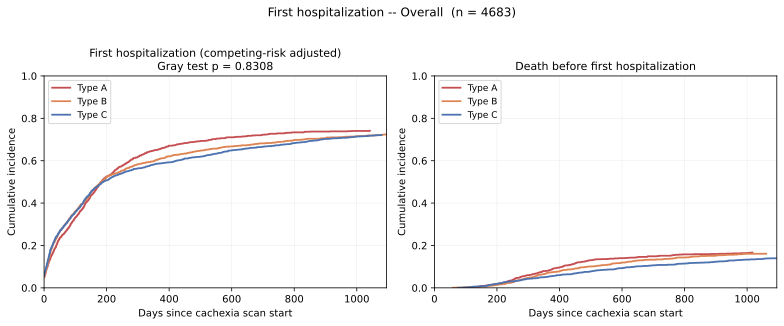

Gray p = 0.8308
naive % ever_hospitalized, censoring at death: Type A 74.7%, Type B 74.4%, Type C 74.7%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0140  0.0102  0.0147
            365           0.0809  0.0717  0.0535
            730           0.1516  0.1349  0.1080
hosp        180           0.4975  0.4971  0.4900
            365           0.6535  0.6066  0.5860
            730           0.7272  0.6847  0.6703

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.5667,1.3465,1.8229,0.0000
2,Type B,1.0727,0.9316,1.2351,0.3294


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.0861,0.9991,1.1808,0.0526
1,Type B,1.0289,0.9522,1.1118,0.4706


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.0198,0.9383,1.1084,0.6446
1,Type B,1.0034,0.9286,1.0841,0.9324


In [30]:
cr_hosp_overall = run_cr_analysis(cr_df, 'Overall', 'overall',
                                 event_name='hosp',
                                 event_label='First hospitalization',
                                 origin_label='cachexia scan start',
                                 time_col='cr_time', event_col='cr_event',
                                 count_col='n_admissions', person_years_col='person_years',
                                 naive_col='ever_hospitalized',
                                 horizons=(180, 365, 730), xmax=1095)


Breast Cancer


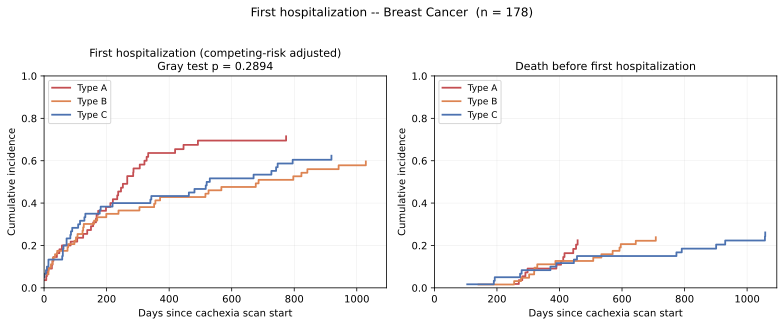

Gray p = 0.2894
naive % ever_hospitalized, censoring at death: Type A 72.7%, Type B 63.5%, Type C 65.0%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0000  0.0159  0.0167
            365           0.0909  0.1111  0.0833
            730           0.2242  0.2390  0.1500
hosp        180           0.3636  0.3333  0.3667
            365           0.6364  0.4127  0.4333
            730           0.6949  0.5097  0.5518

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.2732,0.6262,2.5885,0.5047
2,Type B,0.8605,0.4321,1.7139,0.6691


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.5217,0.9681,2.3921,0.0689
1,Type B,0.9076,0.5819,1.4158,0.6692


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.2802,0.8221,1.9934,0.2743
1,Type B,0.9214,0.5927,1.4325,0.7162



Colorectal Cancer


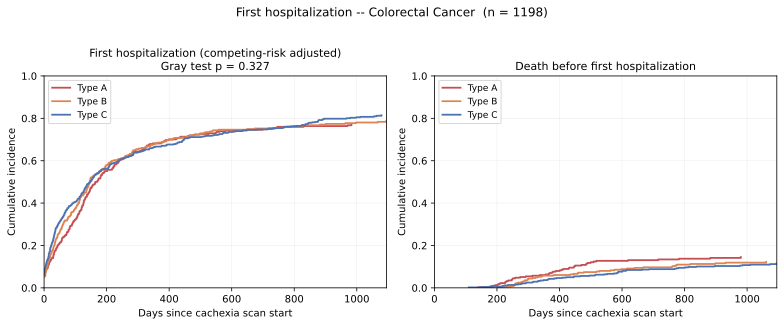

Gray p = 0.327
naive % ever_hospitalized, censoring at death: Type A 77.1%, Type B 80.3%, Type C 81.7%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0064  0.0000  0.0039
            365           0.0637  0.0578  0.0405
            730           0.1341  0.0971  0.0883
hosp        180           0.5223  0.5534  0.5511
            365           0.6815  0.6852  0.6667
            730           0.7530  0.7550  0.7519

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.5054,1.1350,1.9967,0.0045
2,Type B,1.1747,0.8968,1.5389,0.2424


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,0.9256,0.7902,1.0843,0.3384
1,Type B,0.9730,0.8383,1.1294,0.7192


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,0.8855,0.7561,1.037,0.1313
1,Type B,0.9650,0.8315,1.120,0.6393



Endometrial Cancer


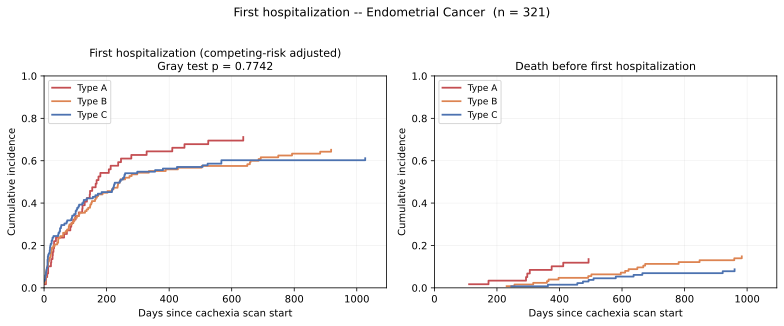

Gray p = 0.7742
naive % ever_hospitalized, censoring at death: Type A 72.9%, Type B 69.3%, Type C 70.4%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0339  0.0000  0.0000
            365           0.0847  0.0394  0.0148
            730           0.1356  0.1129  0.0692
hosp        180           0.5424  0.4409  0.4444
            365           0.6441  0.5512  0.5556
            730           0.7119  0.6162  0.6022

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.7853,0.9187,3.4696,0.0873
2,Type B,1.4012,0.8293,2.3676,0.2074


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.1539,0.8035,1.6570,0.4383
1,Type B,0.9594,0.7174,1.2831,0.7801


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.0639,0.7417,1.5259,0.7365
1,Type B,0.9414,0.7043,1.2583,0.6832



Esophagogastric Cancer


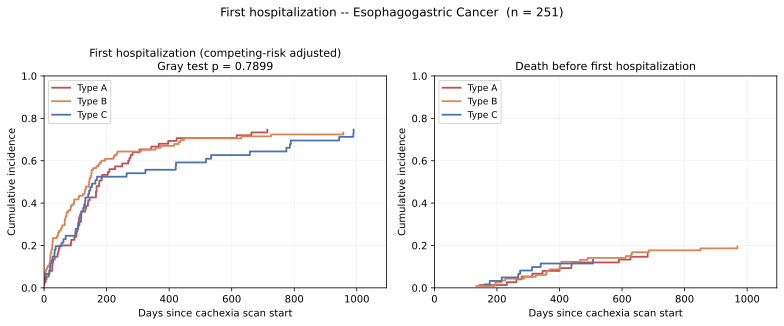

Gray p = 0.7899
naive % ever_hospitalized, censoring at death: Type A 74.7%, Type B 73.9%, Type C 75.4%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0133  0.0087  0.0328
            365           0.0800  0.0783  0.1148
            730           0.1600  0.1772  0.1320
hosp        180           0.5067  0.5913  0.5246
            365           0.6667  0.6609  0.5574
            730           0.7467  0.7238  0.6437

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.0715,0.5513,2.0827,0.8386
2,Type B,0.8261,0.4481,1.5231,0.5406


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.0481,0.7088,1.5498,0.8139
1,Type B,1.1735,0.8189,1.6815,0.3834


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.0139,0.6862,1.4980,0.9449
1,Type B,1.1193,0.7817,1.6028,0.5383



Hepatobiliary Cancer


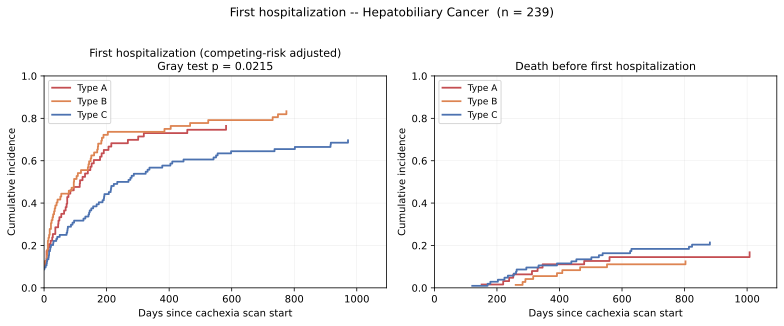

Gray p = 0.0215
naive % ever_hospitalized, censoring at death: Type A 76.2%, Type B 84.7%, Type C 73.1%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0159  0.0000  0.0288
            365           0.1111  0.0556  0.1058
            730           0.1451  0.1111  0.1837
hosp        180           0.6190  0.6806  0.4038
            365           0.7302  0.7361  0.5673
            730           0.7642  0.7917  0.6447

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.8890,0.9524,3.7467,0.0687
2,Type B,1.3499,0.6990,2.6071,0.3716


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.3618,0.9472,1.9579,0.0955
1,Type B,1.6000,1.1401,2.2454,0.0066


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.3282,0.9244,1.9084,0.1248
1,Type B,1.6083,1.1463,2.2567,0.0060



Non-Small Cell Lung Cancer


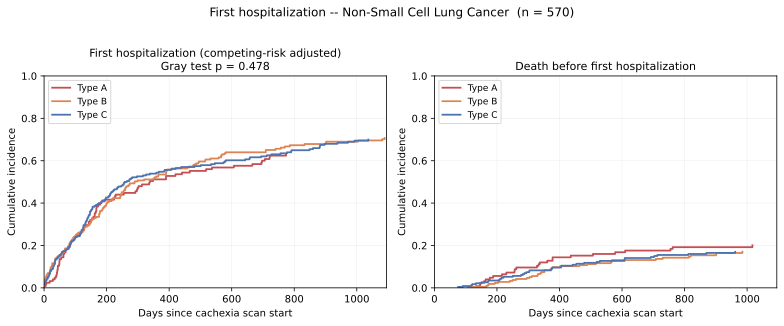

Gray p = 0.478
naive % ever_hospitalized, censoring at death: Type A 64.8%, Type B 71.6%, Type C 70.9%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180            0.048  0.0186  0.0348
            365            0.128  0.0837  0.0826
            730            0.176  0.1423  0.1551
hosp        180            0.400  0.3628  0.4000
            365            0.512  0.5302  0.5435
            730            0.624  0.6506  0.6302

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,0.8984,0.6182,1.3057,0.5744
2,Type B,0.9396,0.6842,1.2902,0.7002


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,0.8839,0.6770,1.1539,0.3641
1,Type B,0.9957,0.7987,1.2413,0.9697


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,0.8633,0.6614,1.1270,0.2797
1,Type B,1.0049,0.8062,1.2526,0.9655



Ovarian Cancer


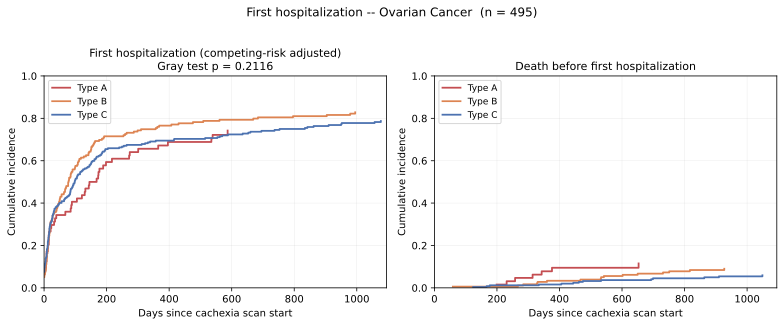

Gray p = 0.2116
naive % ever_hospitalized, censoring at death: Type A 75.0%, Type B 86.0%, Type C 81.3%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0000  0.0056  0.0119
            365           0.0781  0.0335  0.0159
            730           0.1152  0.0670  0.0450
hosp        180           0.5625  0.6983  0.6270
            365           0.6719  0.7598  0.6946
            730           0.7422  0.8045  0.7410

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.6178,0.8476,3.0881,0.1447
2,Type B,0.9492,0.6046,1.4904,0.8209


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,0.8915,0.6507,1.2214,0.4747
1,Type B,1.1818,0.9583,1.4574,0.1183


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,0.8492,0.6201,1.1629,0.3082
1,Type B,1.1364,0.9218,1.4009,0.2310



Pancreatic Cancer


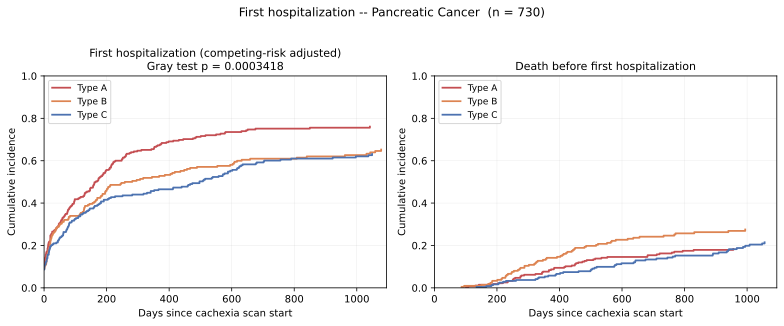

Gray p = 0.0003418
naive % ever_hospitalized, censoring at death: Type A 76.7%, Type B 64.6%, Type C 65.8%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0145  0.0236  0.0082
            365           0.0764  0.1415  0.0576
            730           0.1623  0.2413  0.1384
hosp        180           0.5236  0.4292  0.3992
            365           0.6727  0.5236  0.4609
            730           0.7514  0.6093  0.6008

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,2.2168,1.5517,3.1670,0.0000
2,Type B,1.1841,0.8061,1.7394,0.3892


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.6221,1.3163,1.9989,0.0000
1,Type B,1.1737,0.9334,1.4759,0.1706


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.4253,1.1598,1.7516,0.0008
1,Type B,1.0336,0.8227,1.2986,0.7763



Prostate Cancer


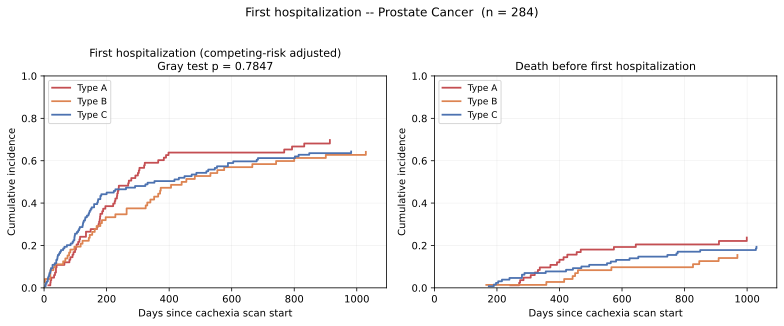

Gray p = 0.7847
naive % ever_hospitalized, censoring at death: Type A 68.7%, Type B 68.1%, Type C 69.0%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 180           0.0000  0.0139  0.0078
            365           0.0964  0.0278  0.0775
            730           0.2048  0.0972  0.1473
hosp        180           0.3494  0.3056  0.4341
            365           0.6024  0.4444  0.5039
            730           0.6386  0.5839  0.6124

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.4724,0.8652,2.5057,0.1538
2,Type B,0.9653,0.5551,1.6787,0.9006


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.1071,0.7912,1.5490,0.5529
1,Type B,0.8481,0.5983,1.2023,0.3549


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.0068,0.7216,1.4048,0.9681
1,Type B,0.9020,0.6364,1.2785,0.5624


In [31]:
cr_hosp_counts = cr_df.groupby(['CANCER_TYPE', 'cluster_name']).size().unstack(fill_value=0)
cr_hosp_ctypes = list(cr_hosp_counts[(cr_hosp_counts >= 50).all(axis=1)].index)
for cancer_type in cr_hosp_ctypes:
    print('\n' + cancer_type)
    run_cr_analysis(cr_df[cr_df['CANCER_TYPE'] == cancer_type], cancer_type,
                    cancer_type.lower().replace(' ', '_').replace('-', '_'),
                    event_name='hosp',
                    event_label='First hospitalization',
                    origin_label='cachexia scan start',
                    time_col='cr_time', event_col='cr_event',
                    count_col='n_admissions', person_years_col='person_years',
                    naive_col='ever_hospitalized',
                    horizons=(180, 365, 730), xmax=1095)

## 11.4 readmission

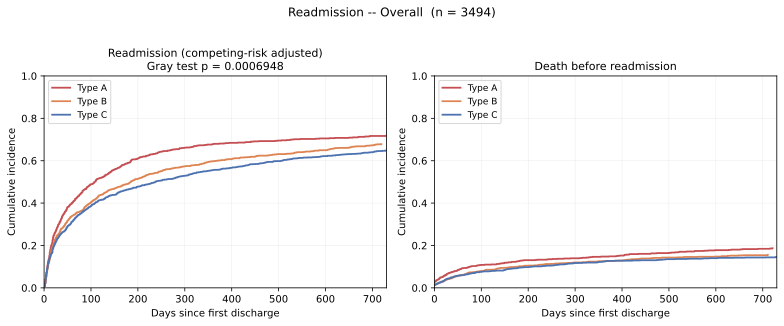

Gray p = 0.0006948
naive % readmitted_30d, censoring at death: Type A 50.2%, Type B 44.1%, Type C 44.4%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 30            0.0685  0.0413  0.0449
            90            0.1050  0.0758  0.0737
            365           0.1476  0.1262  0.1258
readmit     30            0.2983  0.2529  0.2370
            90            0.4709  0.3884  0.3712
            365           0.6796  0.5985  0.5569

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.7691,1.4704,2.1285,0.0000
2,Type B,1.0625,0.8954,1.2609,0.4875


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.3758,1.2466,1.5183,0.0000
1,Type B,1.0717,0.9779,1.1745,0.1384


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.1865,1.0756,1.3088,0.0006
1,Type B,1.0460,0.9545,1.1463,0.3357


In [32]:
cr_readmit_overall = run_cr_analysis(readmit_df, 'Overall', 'overall',
                                    event_name='readmit',
                                    event_label='Readmission',
                                    origin_label='first discharge',
                                    time_col='cr2_time', event_col='cr2_event',
                                    count_col='n_readmissions',
                                    person_years_col='readmission_person_years',
                                    naive_col='readmitted_30d',
                                    horizons=(30, 90, 365), xmax=730)


Colorectal Cancer


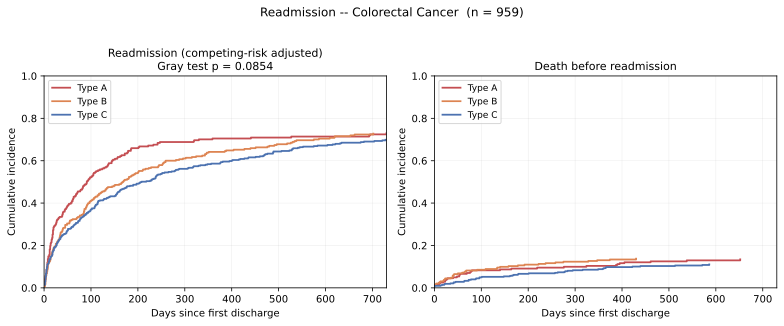

Gray p = 0.0854
naive % readmitted_30d, censoring at death: Type A 49.2%, Type B 44.0%, Type C 46.9%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 30            0.0455  0.0444  0.0189
            90            0.0828  0.0820  0.0448
            365           0.1036  0.1303  0.0954
readmit     30            0.3264  0.2253  0.2193
            90            0.4924  0.3826  0.3491
            365           0.7049  0.6414  0.5860

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,2.0294,1.4462,2.8479,0.0000
2,Type B,1.2183,0.8841,1.6789,0.2274


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.3398,1.1150,1.6100,0.0018
1,Type B,1.1333,0.9527,1.3481,0.1578


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.2097,1.0070,1.4532,0.0419
1,Type B,1.0354,0.8705,1.2314,0.6946



Non-Small Cell Lung Cancer


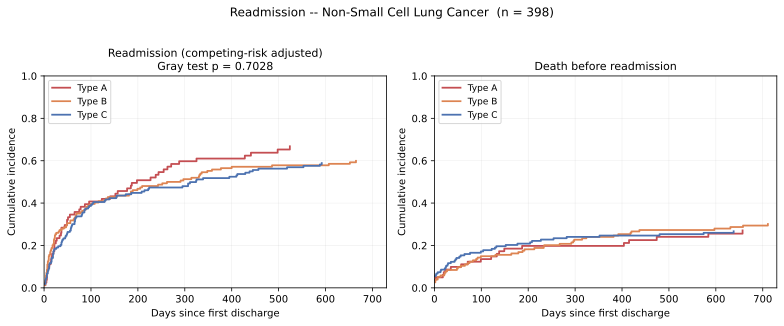

Gray p = 0.7028
naive % readmitted_30d, censoring at death: Type A 38.3%, Type B 39.6%, Type C 37.4%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 30            0.0864  0.0844  0.1166
            90            0.1235  0.1364  0.1656
            365           0.1980  0.2403  0.2468
readmit     30            0.2346  0.2597  0.1963
            90            0.3951  0.3831  0.3742
            365           0.6102  0.5584  0.5180

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,1.0184,0.6413,1.6173,0.9384
2,Type B,0.9494,0.6472,1.3927,0.7905


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.1606,0.8341,1.6149,0.3770
1,Type B,1.0138,0.7681,1.3382,0.9228


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.1389,0.8192,1.5833,0.4392
1,Type B,1.0278,0.7788,1.3563,0.8465



Pancreatic Cancer


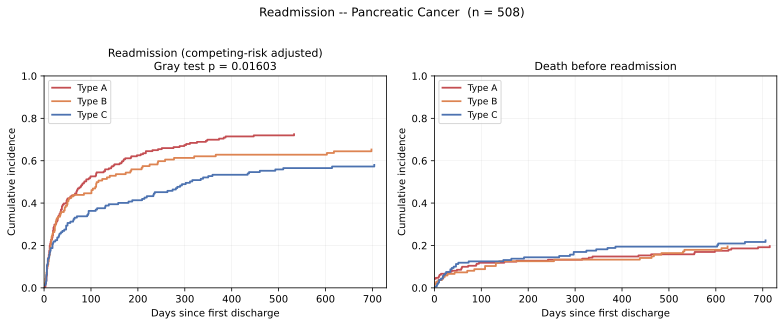

Gray p = 0.01603
naive % readmitted_30d, censoring at death: Type A 54.5%, Type B 48.9%, Type C 39.4%


cluster_name              Type A  Type B  Type C
cause       horizon_days                        
death_first 30            0.0711  0.0657  0.0750
            90            0.1137  0.0880  0.1251
            365           0.1478  0.1333  0.1820
readmit     30            0.3365  0.3358  0.2375
            90            0.5118  0.4463  0.3377
            365           0.6991  0.6208  0.5336

,term,rate_ratio,ci_lower,ci_upper,p
1,Type A,2.0137,1.2881,3.1480,0.0021
2,Type B,1.1688,0.7113,1.9205,0.5382


,term,cause_specific_HR,ci_lower,ci_upper,p
0,Type A,1.5573,1.2097,2.0049,0.0006
1,Type B,1.2550,0.9473,1.6627,0.1135


,term,subdistribution_HR,ci_lower,ci_upper,p
0,Type A,1.4236,1.1072,1.8304,0.0059
1,Type B,1.2498,0.9435,1.6555,0.1201


In [33]:
cr_readmit_counts = readmit_df.groupby(['CANCER_TYPE', 'cluster_name']).size().unstack(fill_value=0)
cr_readmit_ctypes = list(cr_readmit_counts[(cr_readmit_counts >= 50).all(axis=1)].index)
for cancer_type in cr_readmit_ctypes:
    print('\n' + cancer_type)
    run_cr_analysis(readmit_df[readmit_df['CANCER_TYPE'] == cancer_type], cancer_type,
                    cancer_type.lower().replace(' ', '_').replace('-', '_'),
                    event_name='readmit',
                    event_label='Readmission',
                    origin_label='first discharge',
                    time_col='cr2_time', event_col='cr2_event',
                    count_col='n_readmissions',
                    person_years_col='readmission_person_years',
                    naive_col='readmitted_30d',
                    horizons=(30, 90, 365), xmax=730)

## 11.5 summary and export

In [34]:
cr_summary_rate = pd.concat([r['rate'] for r in all_cr_results], ignore_index=True)
cr_summary_rate = cr_summary_rate[(cr_summary_rate['term'] != 'intercept')
                                  & (cr_summary_rate['group'] == 'Overall')]
display(cr_summary_rate[['outcome', 'term', 'rate_ratio', 'ci_lower', 'ci_upper', 'p']].round(4))

cr_summary_gray = pd.concat([r['gray'] for r in all_cr_results], ignore_index=True)
display(cr_summary_gray[['outcome', 'group', 'n', 'gray_p']].round(5))

for result_key in ['gray', 'rate', 'cs', 'fg', 'horizons', 'curves']:
    combined_df = pd.concat([r[result_key] for r in all_cr_results], ignore_index=True)
    combined_df.to_csv(CR_EXPORT_DIR / (result_key + '.csv'), index=False)
    print(result_key + '.csv', len(combined_df), 'rows')

cr_df.to_csv(CR_EXPORT_DIR / 'patient_level_competing_risks.csv', index=False)
print('patient_level_competing_risks.csv', len(cr_df), 'rows')

,outcome,term,rate_ratio,ci_lower,ci_upper,p
1,hosp,Type A,1.5667,1.3465,1.8229,0.0000
2,hosp,Type B,1.0727,0.9316,1.2351,0.3294
31,readmit,Type A,1.7691,1.4704,2.1285,0.0000
32,readmit,Type B,1.0625,0.8954,1.2609,0.4875


,outcome,group,n,gray_p
0,hosp,Overall,4683,0.83083
1,hosp,Breast Cancer,178,0.28938
2,hosp,Colorectal Cancer,1198,0.32704
3,hosp,Endometrial Cancer,321,0.77416
4,hosp,Esophagogastric Cancer,251,0.78990
5,hosp,Hepatobiliary Cancer,239,0.02150
6,hosp,Non-Small Cell Lung Cancer,570,0.47801
7,hosp,Ovarian Cancer,495,0.21164
8,hosp,Pancreatic Cancer,730,0.00034
9,hosp,Prostate Cancer,284,0.78474


gray.csv 14 rows
rate.csv 42 rows
cs.csv 28 rows
fg.csv 28 rows
horizons.csv 252 rows
curves.csv 7999 rows
patient_level_competing_risks.csv 4683 rows
